# Part 3 Bonus Questions for Kevin Rivero and Stef van Gestel

The bonus questions were done using the PyPSA model build from Part 2. Given that PyPSA optimizes it was difficult to maintain a complete baseline across all elements - we were not able to fully control the parameters of heat storage without breaking our model. But all other elements were controlled for and to observe changes in relation to Part 2 - Scenario 2A. If changes in design did occur they were noted along with changes to the KPIs. The Part 2 baseline scenario and context is detailed in the cells below, but if you'd like to skip to our question responses you can search in the notebook for "Part 3A" etc.

## Given cells that required minimal or no modification - skip to next section for our model code

In [385]:
import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib

In [386]:
# Student specific given information:
node_lat = 54.6172
node_lon = 9.5776
node_alt = 0

distance12 = 53 #km
distance23 = 89 #km

electricity_demand_multiplier = .54
heat_demand_multiplier = .43
hydrogen_demand_multiplier = .48
hydrogen_production_multiplier = .45

In [387]:
# Create time series with hourly resolution for the given period
year = 2009
month = 2
times = pd.date_range(start='2009-02-01', end='2009-02-28 23:59:59', freq='h', tz='Europe/Amsterdam')

In [388]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [389]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [390]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

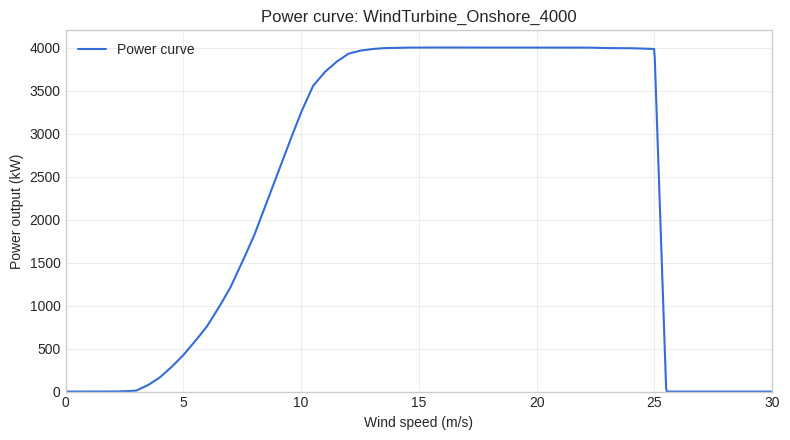

In [391]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [392]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [393]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [394]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [395]:
# Electricity and L/H Heat, Hydrogen demand data for Point 2
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'
df_p2 = pd.read_excel(demand_data_path, sheet_name='Point2', header=1)

el_demand2 = df_p2['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
el_demand2 = el_demand2 * electricity_demand_multiplier

L_heat_demand2 = df_p2['Low T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
L_heat_demand2 = L_heat_demand2 * heat_demand_multiplier

H_heat_demand2 = df_p2['High T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
H_heat_demand2 = H_heat_demand2 * heat_demand_multiplier

hydrogen_demand2 = df_p2['H2 Demand [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
hydrogen_demand2 = hydrogen_demand2 * hydrogen_demand_multiplier

In [396]:
# Hydrogen availability at production

H2_available = df_p2['H2 Production [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
H2_available = H2_available * hydrogen_production_multiplier

In [397]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/scipy/optimize/_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


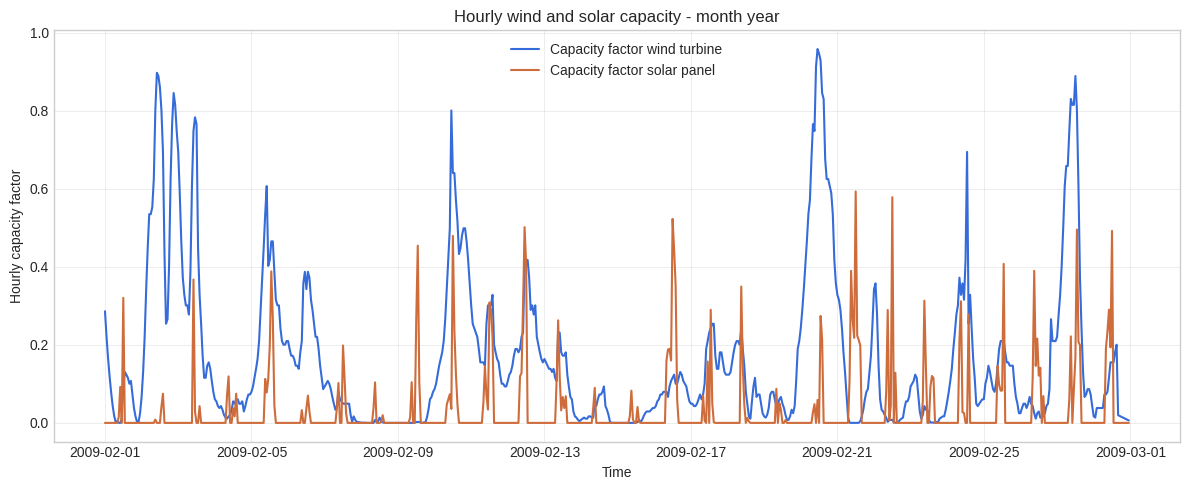

In [398]:
# Plot of capacity factors

plt.figure(figsize=(12, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [399]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost')  # EUR/kW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # capex/year

## Start of our Part 2 model code
### Bring in additional techno-economic data

In [400]:
# grab additional techno-economic data
Solar_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost')  #EUR/kw
Solar_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
Solar_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year math included
Electricity_cable_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kw/km
Electricity_cable_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime') # year
Electricity_cable_fixed_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100 # %capex/year
Electricity_cable_losses = get_value(tech_eco_data, 'Electricity cable', 'Losses') / 100 # % per 100km

# relevant for part 2
Hydrogen_pipeline_capex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Investment cost') # Eur/kw/km
Hydrogen_pipeline_lifetime = get_value(tech_eco_data, 'Hydrogen pipeline', 'Lifetime') # year
Hydrogen_pipeline_fixed_opex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Fixed Opex') /100 # % capex/year
Hydrogen_pipeline_losses = get_value(tech_eco_data, 'Hydrogen pipeline', 'Losses') /100 # % per 100km

Li_ion_battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') # EUR/kWh
Li_ion_battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Li_ion_battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Li_ion_battery_charging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') / 100 # % input energy
Li_ion_battery_discharging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') / 100 # % output energy
Li_ion_battery_self_discharge_coefficient = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') / 100 # % per hour
Li_ion_battery_max_charging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') / 100 # % size of battery
Li_ion_battery_max_discharging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') / 100 # % size of battery

# relevant for part 2
Hydrogen_storage_tank_capex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Investment cost') # EUR/kWh
Hydrogen_storage_tank_lifetime = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Lifetime') #year
Hydrogen_storage_tank_opex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Opex') / 100 # % capex/year
Hydrogen_storage_tank_charging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Charging efficiency') / 100 # % input energy
Hydrogen_storage_tank_discharging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank','Discharging efficiency') # error in data this does not need division by 100 % output energy
Hydrogen_storage_tank_self_discharge_coefficient = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Self-discharge coefficient') / 100# %/hour
Hydrogen_storage_tank_max_charging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max charging capacity') / 100 # %/size
Hydrogen_storage_tank_max_discharging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max discharging capacity') / 100 # %/size
Hydrogen_storage_tank_max_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max capacity') # MW

Heat_storage_high_temp_capex = get_value(tech_eco_data, 'Heat storage - High temp', 'Investment cost') # EUR/MWh
Heat_storage_high_temp_lifetime = get_value(tech_eco_data, 'Heat storage - High temp', 'Lifetime') # year
Heat_storage_high_temp_opex = get_value(tech_eco_data, 'Heat storage - High temp', 'Opex') / 100 # % capex/year
Heat_storage_high_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp', 'Charging efficiency') / 100 # % input energy
Heat_storage_high_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp','Discharging efficiency') / 100 # % output energy
Heat_storage_high_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - High temp', 'Self-discharge coefficient') # % / hour
Heat_storage_high_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max charging capacity') / 100 # % size
Heat_storage_high_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max discharging capacity') / 100 # % size

Heat_storage_low_temp_capex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Investment cost') # EUR/MWh
Heat_storage_low_temp_lifetime = get_value(tech_eco_data, 'Heat storage - Low temp', 'Lifetime') # year
Heat_storage_low_temp_opex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Opex') /100 # % capex/year
Heat_storage_low_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp', 'Charging efficiency') / 100 # % input energy
Heat_storage_low_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp','Discharging efficiency') / 100# % output energy
Heat_storage_low_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - Low temp', 'Self-discharge coefficient') / 100 # % / hour
Heat_storage_low_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max charging capacity') / 100 # % size
Heat_storage_low_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max discharging capacity') / 100 # % size

Heat_pump_coefficient_of_performance = get_value(tech_eco_data, 'Heat pump', 'COP') # no unit
Hydrogen_boiler_efficiency = get_value(tech_eco_data, 'Hydrogen boiler', 'Efficiency') / 100 # % input energy
Operational_cost_lost_load_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Operational_cost_max_import_availability = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Operational_cost_electricity_import_cost = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh
Operational_cost_hydrogen_market_price = get_value(tech_eco_data, 'Operational cost', 'Hydrogen market price') # EUR/MWh


## The baseline: PyPSA Model from Part 2
The code below is the baseline model from Part 2 against which we compared/made modifications for the bonus questions. Skip to comparison cells for responses to questions.

In [401]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pypsa
from pypsa.costs import annuity

In [402]:
# data prep and variables

# p_nom_min_solar = 50
marginal_cost_wind = 0 # gave 0 here. assumed included in opex
marginal_cost_solar = 0

# Battery parameters
p_nom_bat_guess = 10  # MW, initial guess
max_p_nom_batt = 500
# battery_energy_capacity = 25  # MWh, from your Li-ion spec
# battery_max_hours = battery_energy_capacity / p_nom_guess
eta_charge = Li_ion_battery_charging_efficiency # eta is efficiency
eta_discharge = Li_ion_battery_discharging_efficiency
max_charge_pu = Li_ion_battery_max_charging_capacity

#transmission
efficiency_transmission_12 = (1 - Electricity_cable_losses) ** (distance12 / 100)  # = 0.9737 for 53km
efficiency_transmission_23 = (1 - Hydrogen_pipeline_losses) ** (distance23 / 100)
p_nom_guess=80

# H2
p_nom_h2 = H2_available.max()
H2_available = H2_available.copy()
H2_available.index = pd.to_datetime(times)
H2_available.index = H2_available.index.tz_localize(None)
p_max_pu_h2 = H2_available / p_nom_h2

# heat storage
p_nom_pipe=80

# annualize the CAPEX
r = 0.05
simulation_hours = len(times)
monthly_annualizer= simulation_hours/8760

annualized_capex_wind = (Wind_capex*1000) * annuity(r, Wind_lifetime)
annualized_capex_solar = (Solar_capex*1000) * annuity(r, Solar_lifetime)
# annualized_capex_wind_manual = 80600 # eur/MW/y
# annualized_capex_solar_manual = 34200 # eur/MW/y
max_hours_bat = 4 #
annualized_capex_battery = (Li_ion_battery_capex*1000) * max_hours_bat * annuity(r, Li_ion_battery_lifetime) #eur/Mwh * h * annuity = eur/MW

annualized_capex_hydrogen_storage = (Hydrogen_storage_tank_capex*1000) * annuity(r, Hydrogen_storage_tank_lifetime) #eur/MWh # unlike battery PyPSA wants this in MWh, for energy capacity
annualized_capex_heat_high_storage = (Heat_storage_high_temp_capex) * annuity(r, Heat_storage_high_temp_lifetime) # capex already in MWh
annualized_capex_heat_low_storage = (Heat_storage_low_temp_capex) * annuity(r, Heat_storage_low_temp_lifetime)
# capital_cost_power ≈ (1 / C_rate) × capital_cost_energy


annualized_capex_transmission = (Electricity_cable_capex*1000) * distance12 * annuity(r, Electricity_cable_lifetime) # Eur/kw/km * 1000 * km
annualized_capex_pipeline = (Hydrogen_pipeline_capex*1000) * distance23 * annuity(r, Hydrogen_pipeline_lifetime) # eur/kW/km * 1000 * km

#annualize the OPEX
annualized_opex_wind = (Wind_capex * 1000) * Wind_opex  # overnight capex * % = €/MW/year
annualized_opex_solar = (Solar_capex * 1000) * Solar_opex
annualized_opex_battery = (Li_ion_battery_capex * 1000) * Li_ion_battery_opex

annualized_opex_hydrogen_storage = (Hydrogen_storage_tank_capex*1000) * Hydrogen_storage_tank_opex
annualized_opex_heat_high_storage = (Heat_storage_high_temp_capex) * Heat_storage_high_temp_opex # in MWh already so no convert
annualized_opex_heat_low_storage = (Heat_storage_low_temp_capex) * Heat_storage_low_temp_opex

annualized_opex_transmission = (Electricity_cable_capex* 1000) * distance12 * Electricity_cable_fixed_opex # fixme is fixed different?
annualized_opex_pipeline = (Hydrogen_pipeline_capex* 1000) * distance23 * Hydrogen_pipeline_fixed_opex

capital_cost_solar = (annualized_capex_solar + annualized_opex_solar)*monthly_annualizer
capital_cost_wind = (annualized_capex_wind + annualized_opex_wind)*monthly_annualizer
capital_cost_battery = (annualized_capex_battery + annualized_opex_battery)*monthly_annualizer #confusion around whether multiplying by max hours is needed but I think correct
capital_cost_hydrogen_storage = (annualized_capex_hydrogen_storage + annualized_opex_hydrogen_storage)*monthly_annualizer
capital_cost_heat_high_storage = (annualized_capex_heat_high_storage + annualized_opex_heat_high_storage) * monthly_annualizer
capital_cost_heat_low_storage = (annualized_capex_heat_low_storage + annualized_opex_heat_low_storage) * monthly_annualizer
capital_cost_transmission = (annualized_capex_transmission + annualized_opex_transmission)*monthly_annualizer
capital_cost_pipeline = (annualized_capex_pipeline + annualized_opex_pipeline) * monthly_annualizer

heat_high_charge_capex = (1/Heat_storage_high_temp_max_charging_capacity)* annualized_capex_heat_high_storage * monthly_annualizer
heat_low_charge_capex = (1/Heat_storage_low_temp_max_charging_capacity)* annualized_capex_heat_low_storage * monthly_annualizer
#discharge is same %

# conversions timestamp based index vs. integer, repulling from df_p2 so need to re-multiply
el_demand2 = df_p2['Electricity [MWh]'].iloc[skip : skip + len(times)]
el_demand2 = el_demand2.set_axis(times)
el_demand2 = el_demand2 * electricity_demand_multiplier
el_demand2.index = pd.to_datetime(el_demand2.index).tz_localize(None)

L_heat_demand2 = df_p2['Low T Heat [MWh]'].iloc[skip : skip + len(times)]
L_heat_demand2 = L_heat_demand2.set_axis(times)
L_heat_demand2 = L_heat_demand2 * heat_demand_multiplier
L_heat_demand2.index = pd.to_datetime(L_heat_demand2.index).tz_localize(None)

H_heat_demand2 = df_p2['High T Heat [MWh]'].iloc[skip : skip + len(times)]
H_heat_demand2 = H_heat_demand2.set_axis(times)
H_heat_demand2 = H_heat_demand2 * heat_demand_multiplier
H_heat_demand2.index = pd.to_datetime(H_heat_demand2.index).tz_localize(None)

hydrogen_demand2 = df_p2['H2 Demand [MWh]'].iloc[skip : skip + len(times)]
hydrogen_demand2 = hydrogen_demand2.set_axis(times)
hydrogen_demand2 = hydrogen_demand2 * hydrogen_demand_multiplier
hydrogen_demand2.index = pd.to_datetime(hydrogen_demand2.index).tz_localize(None)

H2_available = df_p2['H2 Production [MWh]'].iloc[skip : skip + len(times)]
H2_available = H2_available.set_axis(times)
H2_available = H2_available * hydrogen_production_multiplier
H2_available.index = pd.to_datetime(H2_available.index).tz_localize(None)

capacity_factor_wind.index = pd.to_datetime(capacity_factor_wind.index).tz_localize(None)
capacity_factor_solar.index = pd.to_datetime(capacity_factor_solar.index).tz_localize(None)

ts = pd.concat(
    [
        el_demand2.rename("e_load_mw"),
        L_heat_demand2.rename("l_heat_load"),
        H_heat_demand2.rename("h_heat_load"),
        hydrogen_demand2.rename("hydrogen_demand"),
        H2_available.rename("H2_available"),
        capacity_factor_wind.rename("wind_pu"),
        capacity_factor_solar.rename("solar_pu"),
    ],
    axis=1
)

# sanity check
assert len(ts) == len(times), f"Time series length mismatch: {len(ts)} vs {len(times)}"

#network setup
RESOLUTION = 1 # hourly
n = pypsa.Network()
ts.index = ts.index.tz_localize(None)
n.set_snapshots(ts.index)
n.snapshot_weightings.loc[:, :] = RESOLUTION

REGIONS = ["zone1", "zone2", "zone3"]

REGION_COORDS = {
    "zone1": {"lat": node_lat, "lon": node_lon},
    "zone2": {"lat": 54.279,  "lon": 10.164},
    "zone3": {"lat": 54.279,  "lon": 11.691},
}

REGION_CARRIERS = {
    "zone1": ["electricity"],
    "zone2": ["electricity", "heat_low_temp", "heat_high_temp", "hydrogen"],
    "zone3": ["hydrogen"],
}

#creating buses per region and carrier e.g. zone1_electricity
for region in REGIONS:
    for carrier in REGION_CARRIERS[region]:
        bus_name = f"{region}_{carrier}"

        n.add(
            "Bus",
            bus_name,
            carrier=carrier,
            x=REGION_COORDS[region]["lon"],
            y=REGION_COORDS[region]["lat"],
        )

def bus(region, carrier):
    assert region in REGIONS
    assert carrier in REGION_CARRIERS[region]
    return f"{region}_{carrier}"

carriers = [
    # Energy carriers (core system)
    "electricity",
    "heat_low_temp",
    "heat_high_temp",
    "hydrogen",

    # Generation
    "wind",
    "solar",

    # Storage
    "battery",
    "hydrogen storage",
    "heat_low_storage",
    "heat_high_storage",

    # Conversion / system
    # "electrolysis",
    "heat pump",
    "h2 boiler",

    # Other
    "hydrogen pipeline",
    "load shedding",
    "imported electricity",
]
colors = [
    # Energy carriers (core system)
    "white",           # electricity
    "lightsalmon",     # heat_low_temp
    "orangered",       # heat_high_temp
    "purple",          # hydrogen

    # Generation
    "dodgerblue",      # wind
    "gold",            # solar

    # Storage
    "darkorange",      # battery
    "mediumpurple",    # hydrogen storage
    "lightcoral",      # heat_low_storage
    "tomato",          # heat_high_storage

    # Conversion / system
    "green",           # heat pump
    "orchid",          # h2 boiler

    # Other
    "lightblue",       # hydrogen pipeline
    "red",             # load shedding
    "lightgreen",      # imported electricity
]
n.add("Carrier", carriers, color=colors)

# COMPONENTS SECTION
# GENERATION
n.add(
    "Generator",
    "solar_zone1",
    bus=bus("zone1", "electricity"),
    carrier="solar",
    p_max_pu=ts.solar_pu,
    capital_cost=capital_cost_solar, # using MW
    marginal_cost=marginal_cost_solar,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
)

n.add("Generator",
    "wind_zone1",
    bus=bus("zone1", "electricity"),
    carrier="wind",
    p_max_pu=ts.wind_pu,
    capital_cost=capital_cost_wind, # using MW
    marginal_cost=marginal_cost_wind,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
)

n.add(
    "Generator",
    "load shedding",
    bus=bus("zone2", "electricity"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.e_load_mw.max(),
    # p_max_pu=0.05,  # at any hour, max shedding = 5% of p_nom
)

n.add(
    "Generator",
    "import",
    bus=bus("zone2", "electricity"),
    carrier="imported electricity",
    marginal_cost=Operational_cost_electricity_import_cost,        # existing variable, €/MWh
    p_nom=Operational_cost_max_import_availability,    # existing variable, MW
    p_nom_extendable=False, # can't expand capacity any more than max
)

n.add(
    "Generator",
    "h2_zone3",
    bus=bus("zone3", "hydrogen"),
    carrier="hydrogen",
    p_nom=p_nom_h2,
    p_max_pu=p_max_pu_h2,
    marginal_cost=Operational_cost_hydrogen_market_price, # eur/MWh
)

n.add("Generator", "loadshed_hydrogen",
    bus=bus("zone2", "hydrogen"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.hydrogen_demand.max())

n.add("Generator", "loadshed_heat_high",
    bus=bus("zone2", "heat_high_temp"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.h_heat_load.max()
)

n.add("Generator", "loadshed_heat_low",
    bus=bus("zone2", "heat_low_temp"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.l_heat_load.max()
)

# DEMAND
# Electricity demand
n.add(
    "Load",
    "electricity_demand",
    bus=bus("zone2", "electricity"),
    carrier="electricity",
    p_set=ts.e_load_mw,
)

# Low-temperature heat demand
n.add(
    "Load",
    "heat_low_demand",
    bus=bus("zone2", "heat_low_temp"),
    carrier="heat_low_temp",
    p_set=ts.l_heat_load,   # make sure this is your low-temp heat time series
)

# High-temperature heat demand
n.add(
    "Load",
    "heat_high_demand",
    bus=bus("zone2", "heat_high_temp"),
    carrier="heat_high_temp",
    p_set=ts.h_heat_load,  # make sure this is your high-temp heat time series
)

# Hydrogen demand
n.add(
    "Load",
    "hydrogen_demand",
    bus=bus("zone2", "hydrogen"),
    carrier="hydrogen",
    p_set=ts.hydrogen_demand,  # hydrogen demand in MW
)

# STORAGE
n.add(
    "StorageUnit",
    "battery storage zone 1", # manually swap batteries
    bus=bus("zone1", "electricity"),
    carrier="battery",
    p_nom=p_nom_bat_guess, #MW
    p_nom_extendable=True,
    p_nom_max=max_p_nom_batt,
    max_hours=max_hours_bat, # E_max = p_nom * max_hours battery can go 4 hours at full discharge
    capital_cost=capital_cost_battery,
    efficiency_store=eta_charge,
    efficiency_dispatch=eta_discharge,
    standing_loss=Li_ion_battery_self_discharge_coefficient,
    p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
    p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
    state_of_charge_initial=0.5 * p_nom_bat_guess * max_hours_bat,
)

# n.add(
#     "StorageUnit",
#     "battery storage zone 2", #manually swap in
#     bus="zone2",
#     carrier="battery storage",
#     p_nom=p_nom_guess, #MW
#     # max_hours=e_nom/p_nom, # E_max = p_nom * max_hours battery can go 3 hours at full discharge
#     capital_cost=capital_cost_battery,
#     efficiency_store=eta_charge,
#     efficiency_dispatch=eta_discharge,
#     standing_loss=0.00004,
#     p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
#     p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
#     e_nom_extendable=True, # allowing capacity to increase in MWh
#     cyclic_state_of_charge=True, #The battery’s state of charge at the end of the simulation equals its starting state. Ensures no net energy accumulation over the optimization horizon. Important for representing a full year or cyclic operation
# )

#h2 storage section - note requires accompanying links to account for charge/discharge parameters
n.add(
    "Bus",
    "h2_storage_internal",
    carrier="hydrogen",
)

n.add(
    "Store",
    "h2_storage_zone3",
    bus="h2_storage_internal",
    carrier="hydrogen storage",
    e_nom_extendable=True,
    e_nom_max = Hydrogen_storage_tank_max_capacity,
    capital_cost=capital_cost_hydrogen_storage,
    e_cyclic=True,           # optional: end level = start level
    standing_loss=Hydrogen_storage_tank_self_discharge_coefficient
)

n.add(
    "Link",
    "h2_charge_zone3",
    bus0=bus("zone3", "hydrogen"),
    bus1="h2_storage_internal",
    efficiency=Hydrogen_storage_tank_charging_efficiency,
    p_nom=Hydrogen_storage_tank_max_charging_capacity * Hydrogen_storage_tank_max_capacity,   # MW = % * MWh assuming % was hourly c-rate
    carrier="hydrogen storage",
)

n.add(
    "Link",
    "h2_discharge_zone3",
    bus0="h2_storage_internal",
    bus1=bus("zone3", "hydrogen"),
    efficiency=Hydrogen_storage_tank_discharging_efficiency,
    p_nom=Hydrogen_storage_tank_max_discharging_capacity * Hydrogen_storage_tank_max_capacity,  # MW = % * MWh assuming % was hourly crate
    carrier="hydrogen storage",
)

# heat storage section
n.add(
    "Bus",
    "heat_low_storage_internal",
    carrier="heat_low_temp",
)

n.add(
    "Bus",
    "heat_high_storage_internal",
    carrier="heat_high_temp",
)

n.add(
    "Store",
    "heat_low_storage",
    bus="heat_low_storage_internal",
    carrier="heat_low_storage",
    e_nom=0,
    e_nom_extendable=True,
    standing_loss=Heat_storage_low_temp_self_discharge_coefficient,
    capital_cost=capital_cost_heat_low_storage,
    e_cyclic=True,
)

n.add(
    "Store",
    "heat_high_storage",
    bus="heat_high_storage_internal",
    carrier="heat_high_storage",
    e_nom=0,
    e_nom_extendable=True,
    standing_loss=Heat_storage_high_temp_self_discharge_coefficient,
    capital_cost=capital_cost_heat_high_storage,
    e_cyclic=True,
)

n.add(
    "Link",
    "heat_low_charge",
    bus0=bus("zone2", "heat_low_temp"),
    bus1="heat_low_storage_internal",
    efficiency=Heat_storage_low_temp_charging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_low_charge_capex, #workaround for max charging capacity inclusion
    carrier="heat_low_storage",
)

n.add(
    "Link",
    "heat_low_discharge",
    bus0="heat_low_storage_internal",
    bus1=bus("zone2", "heat_low_temp"),
    efficiency=Heat_storage_low_temp_discharging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_low_charge_capex, #same rate for discharge
    carrier="heat_low_storage",
)

n.add(
    "Link",
    "heat_high_charge",
    bus0=bus("zone2", "heat_high_temp"),
    bus1="heat_high_storage_internal",
    efficiency=Heat_storage_high_temp_charging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_high_charge_capex,
    carrier="heat_high_storage",
)

n.add(
    "Link",
    "heat_high_discharge",
    bus0="heat_high_storage_internal",
    bus1=bus("zone2", "heat_high_temp"),

    efficiency=Heat_storage_high_temp_discharging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_high_charge_capex,
    carrier="heat_high_storage",
)

#TRANSMISSION
# Electricity line from zone1 to zone2
n.add(
    "Link",
    "zone1-zone2",
    bus0=bus("zone1", "electricity"),
    bus1=bus("zone2", "electricity"),
    efficiency=efficiency_transmission_12,
    p_nom_min = p_nom_guess, # MW max capacity if fixed
    p_nom_extendable=True,        # allows optimization
    p_nom_mod=10, # rule of 10mw sections
    capital_cost=capital_cost_transmission,  # €/MW
    carrier="electricity",
)

#h2 pipeline
# Hydrogen pipeline from zone3 to zone2
n.add(
    "Link",
    "zone3-zone2",
    bus0=bus("zone3", "hydrogen"),
    bus1=bus("zone2", "hydrogen"),
    efficiency=efficiency_transmission_23,
    p_nom_min=p_nom_pipe,
    p_nom_extendable=True,  # optimize pipeline capacity
    capital_cost=capital_cost_pipeline,  # €/MW
    carrier="hydrogen pipeline",
)

#CONVERSION
n.add(
    "Link",
    "heatpump_zone2",
    bus0=bus("zone2", "electricity"),
    bus1=bus("zone2", "heat_low_temp"),
    efficiency=Heat_pump_coefficient_of_performance,
    p_nom_extendable=True,      # lets PyPSA choose size
    # capital_cost=capital_cost_heatpump,  # €/MW_electricity input assume preexisting infra no cost
    carrier="heat pump",
)

n.add(
    "Link",
    "h2_boiler_zone2",
    bus0=bus("zone2", "hydrogen"),
    bus1=bus("zone2", "heat_high_temp"),
    efficiency=Hydrogen_boiler_efficiency,   # fraction of H2 energy converted to heat
    p_nom_extendable=True,              # size is optimized
    # capital_cost=capital_cost_h2_boiler, # assumed this is preexisting infra so no cost
    carrier="h2 boiler",
)

for bus_name in n.buses.index:
    loads = n.loads[n.loads.bus == bus_name].index.tolist()
    gens = n.generators[n.generators.bus == bus_name].index.tolist()
    links_in = n.links[n.links.bus1 == bus_name].index.tolist()
    if loads and not gens and not links_in:
        print(f"ISOLATED: {bus_name} has demand but no supply path")

n.optimize()

/tmp/ipykernel_18596/1812573122.py:542: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing integer variables.: 100%|██████████| 1/1 [00:00<00:00, 236.51it/s]
INFO:linopy.io: Writing time: 0.3s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
MIP linopy-problem-nyza4yh4 has 41009 rows; 18160 cols; 73378 nonzeros; 1 integer variables (0 binary)
Coefficient ranges:
  Matrix  [1e-04, 1e+01]
  Cost    [1e+00, 1e+04]
  Bound   [1e+05, 1e+05]
  RHS     [8e-01, 5e+02]
Presolving model
17585 rows, 17597 cols, 48050 nonzeros  0s
15127 rows, 15533 cols, 43203 nonzeros  0s
Presolve reductions: rows 15127(-25882); columns 15533(-2627); nonzeros 43203(-30175) 

Solving MIP model with:
   15127 rows
   15533 cols (0 binary, 1 integer, 0 implied int., 15532 continuous, 0 domain fixed)
   43203 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper;

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 18160 primals, 41009 duals
Objective: 1.01e+07
Solver model: available
Solver message: Optimal



 T       0       0         0   0.00%   214455.998869   10146621.16703    97.89%        0      0      0     13286     4.4s
         1       0         1 100.00%   10146621.16703  10146621.16703     0.00%        0      0      0     13286     4.4s

Solving report
  Model             linopy-problem-nyza4yh4
  Status            Optimal
  Primal bound      10146621.167
  Dual bound        10146621.167
  Gap               0% (tolerance: 0.01%)
  P-D integral      0.00252399858065
  Solution status   feasible
                    10146621.167 (objective)
                    0 (bound viol.)
                    0 (int. viol.)
                    0 (row viol.)
  Timing            4.44
  Max sub-MIP depth 0
  Nodes             1
  Repair LPs        0
  LP iterations     13286
                    0 (strong br.)
                    0 (separation)
                    0 (heuristics)


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

## What is our baseline dataset like?
Our Part 2 dataset with our assigned parameters was for the Jutland peninsula in Northern Germany in the month February. The demand landscape is more complicated than Part 1. We have electricity demand, but also have demand for high and low temperature heat, as well as hydrogen.

Our primary challenge is that our given multipliers result in demand and production figures for H2 that result in a deficit. In addition to the actual margi, this presents a serious timing mismatch challenge. The chart below shows how little opportunity there is for storage.

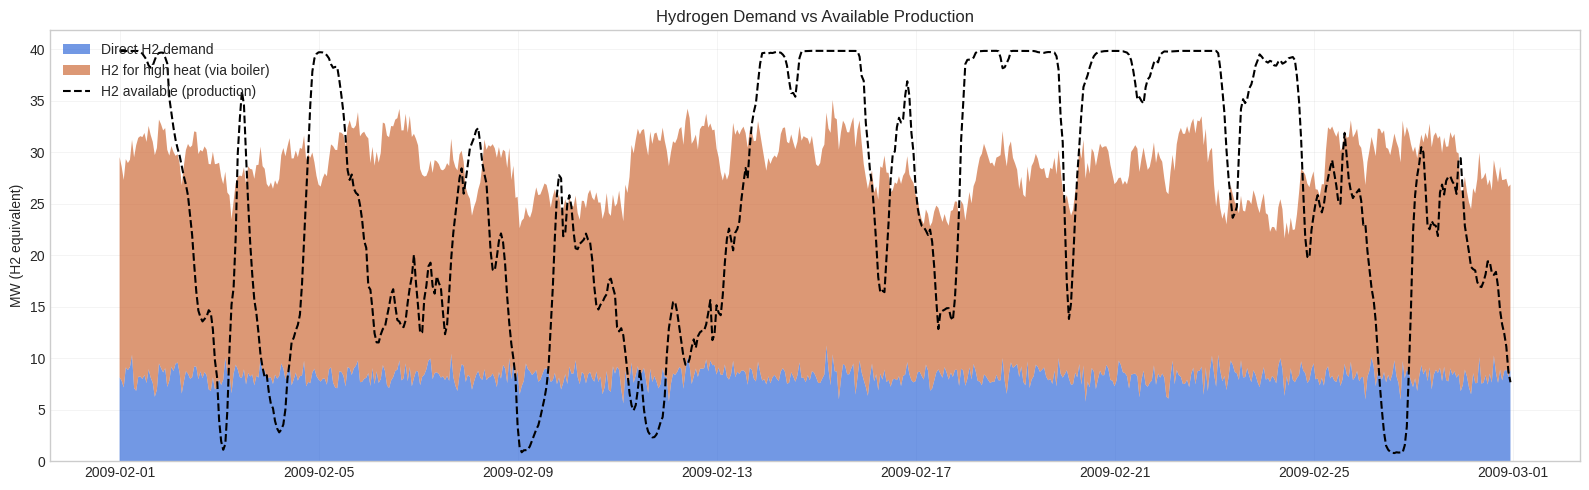

Total H2 available:        17218.6 MWh
Total direct H2 demand:    5562.3 MWh
Total H2 for high heat:    13801.4 MWh
Total H2 demand:           19363.7 MWh
Gap (available - demand):  -2145.1 MWh


In [403]:
# n_full = networks["Full Optimization"]

# Demand
h2_direct_demand = ts.hydrogen_demand
h2_for_heat      = (ts.h_heat_load / Hydrogen_boiler_efficiency) / efficiency_transmission_23
h2_total_demand  = h2_direct_demand + h2_for_heat

# Supply
h2_available    = ts.H2_available
# h2_from_storage = -n_full.links_t.p1["h2_discharge_zone3"]
# h2_to_storage   = n_full.links_t.p0["h2_charge_zone3"]

# Plot 1: Demand stack vs available production
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(16, 5))
ax.stackplot(
    ts.index,
    h2_direct_demand,
    h2_for_heat,
    labels=["Direct H2 demand", "H2 for high heat (via boiler)"],
    alpha=0.7,
)
ax.plot(ts.index, h2_available, color="black", linewidth=1.5,
        linestyle="--", label="H2 available (production)")
ax.set_ylabel("MW (H2 equivalent)")
ax.set_title("Hydrogen Demand vs Available Production")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# # Plot 2: Demand stack vs supply with storage flows
# fig, ax = plt.subplots(figsize=(16, 5))
# ax.stackplot(
#     ts.index,
#     h2_direct_demand,
#     h2_for_heat,
#     labels=["Direct H2 demand", "H2 for high heat (via boiler)"],
#     alpha=0.7,
# )
# ax.plot(ts.index, h2_available, color="black", linewidth=1.5,
#         linestyle="--", label="H2 production available")
# ax.plot(ts.index, h2_from_storage, color="purple", linewidth=1,
#         linestyle=":", label="H2 from storage")
# ax.plot(ts.index, h2_to_storage, color="grey", linewidth=1,
#         linestyle="-.", label="H2 to storage (charging)")
# ax.set_ylabel("MW (H2 equivalent)")
# ax.set_title("Hydrogen Demand vs Supply with Storage — Full Optimization")
# ax.legend(loc="upper left")
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# ── Summary ───────────────────────────────────────────────────────
print(f"Total H2 available:        {h2_available.sum():.1f} MWh")
print(f"Total direct H2 demand:    {h2_direct_demand.sum():.1f} MWh")
print(f"Total H2 for high heat:    {h2_for_heat.sum():.1f} MWh")
print(f"Total H2 demand:           {h2_total_demand.sum():.1f} MWh")
# print(f"Total H2 to storage:       {h2_to_storage.sum():.1f} MWh")
# print(f"Total H2 from storage:     {h2_from_storage.sum():.1f} MWh")
print(f"Gap (available - demand):  {(h2_available.sum() - h2_total_demand.sum()):.1f} MWh")

Load Data

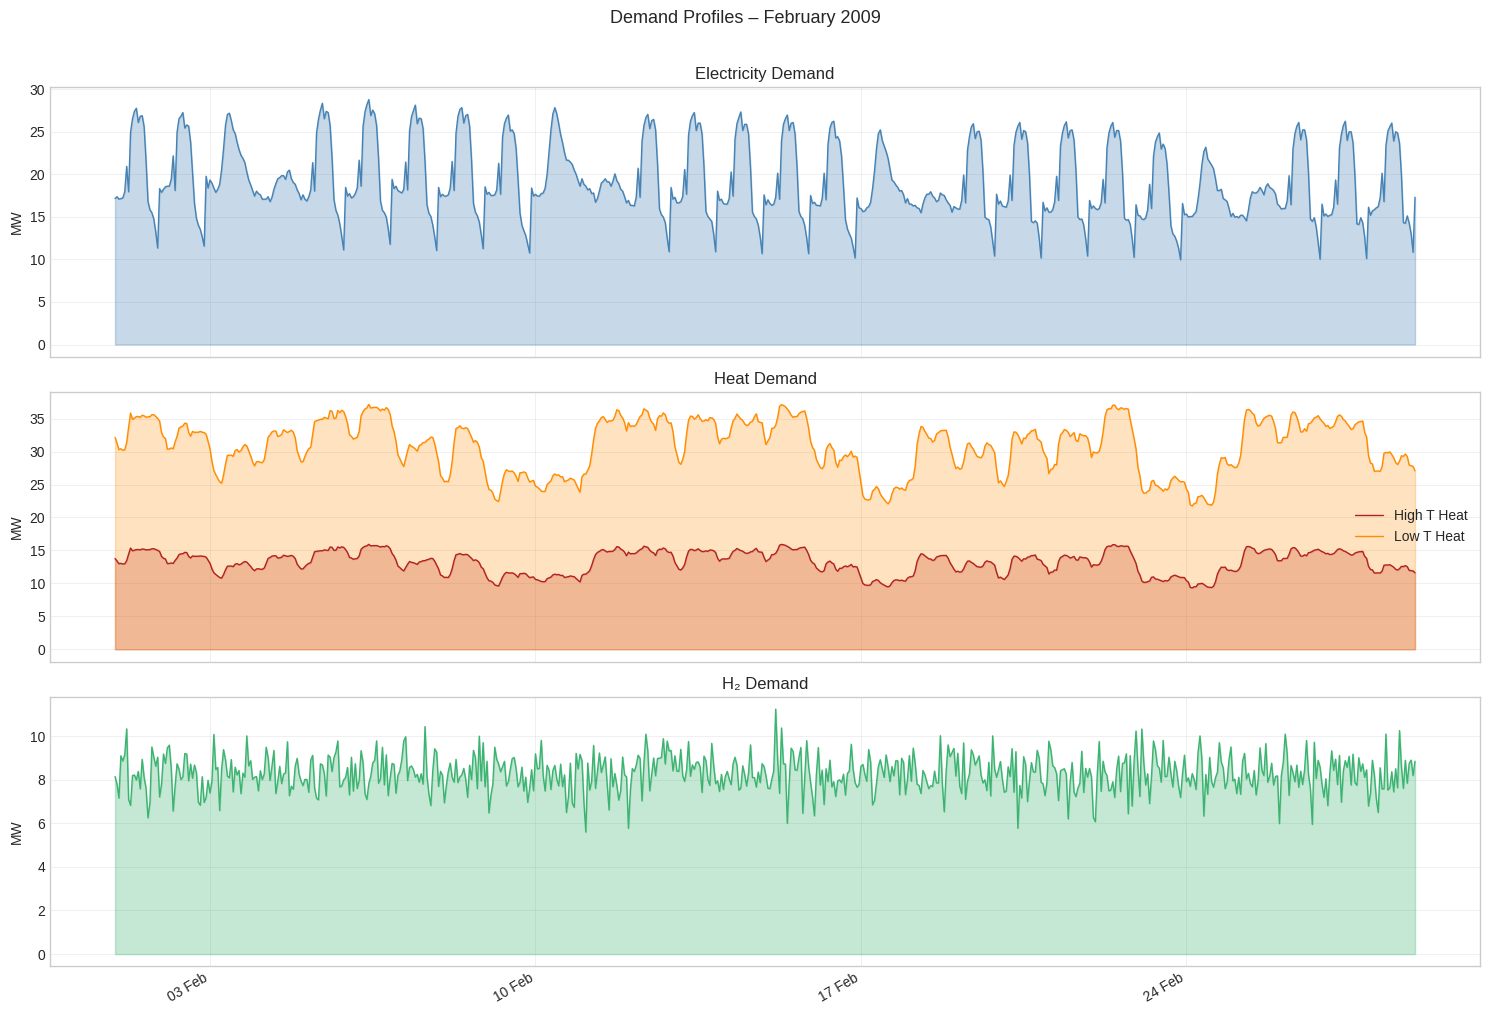

In [404]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
plt.style.use("seaborn-v0_8-whitegrid")

# Electricity demand
axes[0].plot(times, el_demand2.values, color='steelblue', linewidth=1)
axes[0].fill_between(times, el_demand2.values, alpha=0.3, color='steelblue')
axes[0].set_ylabel('MW')
axes[0].set_title('Electricity Demand')
axes[0].grid(True, alpha=0.4)

# Heat demand (High T + Low T together)
axes[1].plot(times, H_heat_demand2.values, label='High T Heat', color='firebrick', linewidth=1)
axes[1].fill_between(times, H_heat_demand2.values, alpha=0.25, color='firebrick')
axes[1].plot(times, L_heat_demand2.values, label='Low T Heat', color='darkorange', linewidth=1)
axes[1].fill_between(times, L_heat_demand2.values, alpha=0.25, color='darkorange')
axes[1].set_ylabel('MW')
axes[1].set_title('Heat Demand')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

#Hydrogen demand
axes[2].plot(times, hydrogen_demand2.values, color='mediumseagreen', linewidth=1)
axes[2].fill_between(times, hydrogen_demand2.values, alpha=0.3, color='mediumseagreen')
axes[2].set_ylabel('MW')
axes[2].set_title('H₂ Demand')
axes[2].grid(True, alpha=0.4)

# Shared x-axis formatting
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate(rotation=30)

plt.suptitle('Demand Profiles – February 2009', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [405]:
n.loads_t.p_set.describe()

name,electricity_demand,heat_low_demand,heat_high_demand,hydrogen_demand
count,672.000000,672.000000,672.000000,672.000000
mean,19.154613,30.871536,13.230658,8.277241
std,4.430892,3.984314,1.707563,0.823964
min,9.957652,21.749628,9.321269,5.598701
25%,16.063072,27.852214,11.936663,7.749594
50%,17.989188,31.570381,13.530163,8.258627
75%,23.222406,34.330614,14.713120,8.808136
max,28.782701,37.163085,15.927037,11.237775


Production Capability

Our electricity capacity factors were the same as in Part 1

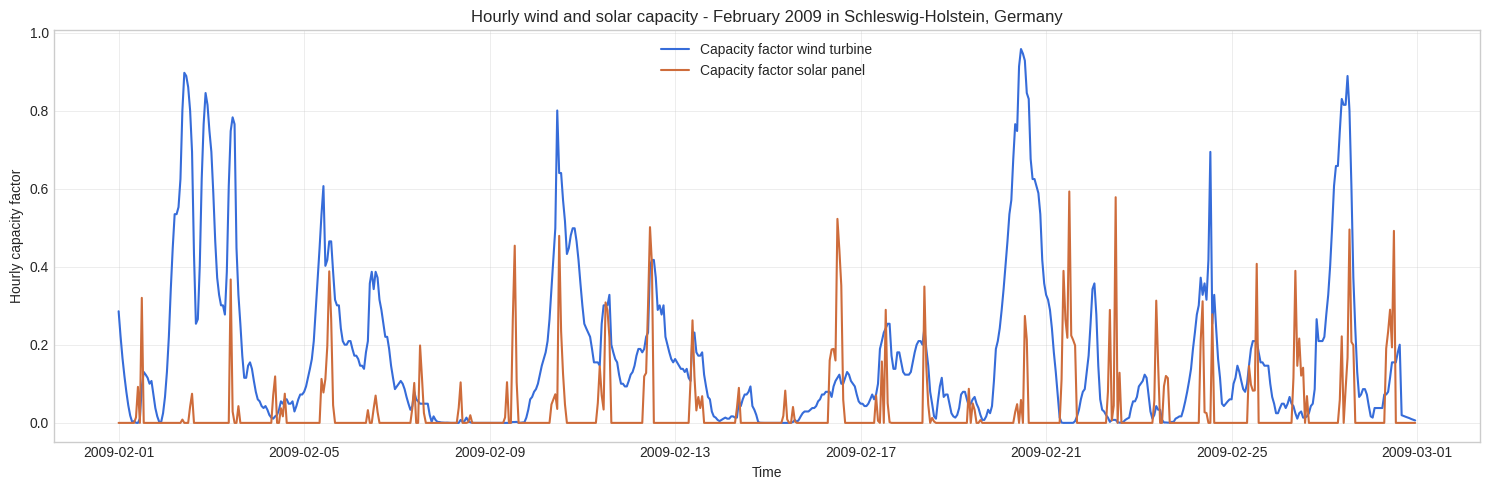

In [406]:
# Plot of capacity factors

plt.figure(figsize=(15, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - February 2009 in Schleswig-Holstein, Germany')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We now also have hourly H2 production data given to us.

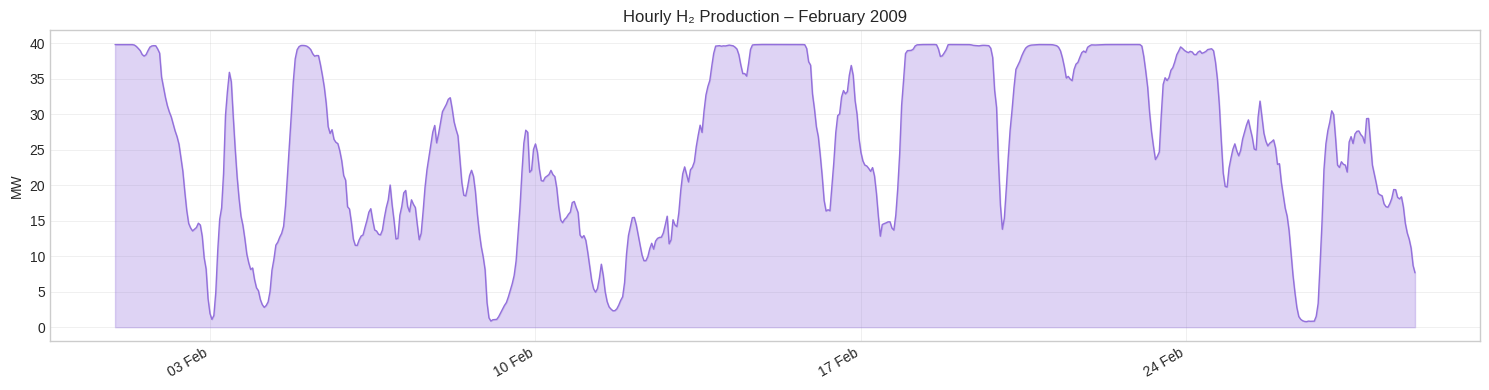

count    672.000000
mean      25.622945
std       12.200231
min        0.784013
25%       15.452480
50%       26.075798
75%       38.911493
max       39.849300
Name: H2 Production [MWh], dtype: float64

In [407]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(times, H2_available.values, color='mediumpurple', linewidth=1)
ax.fill_between(times, H2_available.values, alpha=0.3, color='mediumpurple')

ax.set_ylabel('MW')
ax.set_title('Hourly H₂ Production – February 2009')
ax.grid(True, alpha=0.4)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

H2_available.describe()

## Part 3A: Comparing the impacts of a different weather regime

In section 3A we look at the results of different weather, by moving our location to a different climate (Western Spain) a different season (June) and one year later. We observed how the change in climate/locale affected our system, using the same KPIs (plus a few extra) from Part 2: RES curtailment, unserved demand across energy types, conversion and transport losses (for non electric), total additional cost, transmission utilization for L12, number of hours that L32 is at max capacity, number of hours H2 reservoir is empty or full. (binding storage constraints), curtailment, energy security.

In brief, the new weather regime is a disaster for our system build. Our build was optimized for gray and windy winter conditions in northern Germany. As such, we focused on wind capacity and ***had 0 solar*** - a huge detriment in the sun soaked west of Spain in June. As might be expected, our observed KPIs of curtailment and congestion dropped as a result of scarcity now being an issue with the non-ideal bearing the load without any help fom solar. We also noted that unserved demand rose by 2000 MWh -  but not from the expected electricity. The uncontrolled heat storage PyPSA variables had cascading economic effects and the optimizer chose to build less, most likely because the cost of our build has already risen greatly. Finally, our energy security KPI went out the window with domestic import. Electricity imports now double domestic production in order to meet our demand.

In summary, our wind-focused build suffered in a totally different climate regime.

### KPI Overview
Scenarios were analyzed for impact across the following KPIs:
- RES curtailment
- unserved demand across energy types
- conversion and transport losses (for non electric)
- total additional cost, transmission utilization for L12
- number of hours that L32 is at max capacity
- number of hours H2 reservoir is empty or full (binding storage constraints).
- Curtailment
- Energy Security

Figures and narrative addressing each KPI are detailed in the sections below.

In [408]:
# Run / load each scenario
# PyPSA scenario runs were saved as netCDF
networks = {
    "Scenario 2A": pypsa.Network("results/scenario_2A.nc"),
    "Weather": pypsa.Network("results/scenario_3A.nc"),
    # "N-1 Loss at L12": pypsa.Network("results/scenario_3B.nc"),
    # "Scenario 2C": pypsa.Network("results/scenario_2C.nc"),
    # "Scenario 2D": pypsa.Network("results/scenario_2D.nc"),
}

for label, n in networks.items():
    stats = n.statistics()
    stats.columns.name = label  # sets the table's column header to the scenario name
    display(stats)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks


Scenario 2A                       Optimal Capacity  Installed Capacity  \
Generator   hydrogen                      39.84930             39.8493   
            imported electricity          25.00000             25.0000   
            load shedding                 93.11060             93.1106   
            wind                         133.41321              0.0000   
Link        electricity                   80.00000              0.0000   
            h2 boiler                     33.48524              0.0000   
            heat pump                     58.85758              0.0000   
            heat_high_storage             24.87013              0.0000   
            heat_low_storage             207.29967              0.0000   
            hydrogen pipeline             80.00000              0.0000   
            hydrogen storage             100.00000            100.0000   
Load        electricity                    0.00000              0.0000   
            heat_high_temp                 0.00000              0.0000   
            heat_low_temp                  0.00000              0.0000   
            hydrogen                       0.00000              0.0000   
StorageUnit battery                        4.42922             10.0000   
Store       heat_high_storage           1029.06748              0.0000   
            heat_low_storage            5565.85312              0.0000   
            hydrogen storage             100.00000              0.0000   

Scenario 2A                            Supply   Withdrawal  Energy Balance  \
Generator   hydrogen              17218.61879      0.00000     17218.61879   
            imported electricity   4976.80334      0.00000      4976.80334   
            load shedding          1637.30315      0.00000      1637.30315   
            wind                  14242.39791      0.00000     14242.39791   
Link        electricity               0.00000  14250.53529    -14250.53529   
            h2 boiler                 0.00000  11456.07698    -11456.07698   
            heat pump                 0.00000   5973.72779     -5973.72779   
            heat_high_storage         0.00000   2821.56478     -2821.56478   
            heat_low_storage          0.00000  28750.99485    -28750.99485   
            hydrogen pipeline         0.00000  17171.29197    -17171.29197   
            hydrogen storage          0.00000    669.12280      -669.12280   
Load        electricity               0.00000  12871.89984    -12871.89984   
            heat_high_temp            0.00000   8891.00246     -8891.00246   
            heat_low_temp             0.00000  20745.67241    -20745.67241   
            hydrogen                  0.00000   5562.30612     -5562.30612   
StorageUnit battery                 232.27544    224.13806         8.13738   
Store       heat_high_storage      1321.25210   1485.30955      -164.05745   
            heat_low_storage      14294.31000  14456.68485      -162.37485   
            hydrogen storage        310.89799    315.23783        -4.33985   

Scenario 2A                       Transmission  Capacity Factor  Curtailment  \
Generator   hydrogen                   0.00000         0.642996      0.00000   
            imported electricity       0.00000         0.296238  11823.19666   
            load shedding              0.00000         0.026167  60933.01854   
            wind                       0.00000         0.158860    908.26986   
Link        electricity            14250.53529         0.265077      0.00000   
            h2 boiler                  0.00000         0.509112      0.00000   
            heat pump                  0.00000         0.151034      0.00000   
            heat_high_storage       2821.56478         0.168827      0.00000   
            heat_low_storage       28750.99485         0.206388      0.00000   
            hydrogen pipeline      17171.29197         0.319407      0.00000   
            hydrogen storage         669.12280         0.009957      0.00000  

Weather                           Optimal Capacity  Installed Capacity  \
Generator   hydrogen                      39.84930            39.84930   
            imported electricity          25.00000            25.00000   
            load shedding                 82.03152            82.03152   
            wind                         133.00000           133.00000   
Link        electricity                   80.00000             0.00000   
            h2 boiler                     32.29293             0.00000   
            heat pump                     38.12301             0.00000   
            heat_high_storage             22.25678             0.00000   
            heat_low_storage             125.88451             0.00000   
            hydrogen pipeline             80.00000             0.00000   
            hydrogen storage             100.00000           100.00000   
Load        electricity                    0.00000             0.00000   
            heat_high_temp                 0.00000             0.00000   
            heat_low_temp                  0.00000             0.00000   
            hydrogen                       0.00000             0.00000   
StorageUnit battery                        4.00000             4.00000   
Store       heat_high_storage            625.89018             0.00000   
            heat_low_storage            1349.10180             0.00000   
            hydrogen storage             100.00000             0.00000   

Weather                                Supply   Withdrawal  Energy Balance  \
Generator   hydrogen              13785.59917      0.00000     13785.59917   
            imported electricity  11002.79154      0.00000     11002.79154   
            load shedding          2662.15754      0.00000      2662.15754   
            wind                   4134.58442      0.00000      4134.58442   
Link        electricity               0.00000   4140.74228     -4140.74228   
            h2 boiler                 0.00000   8463.36110     -8463.36110   
            heat pump                 0.00000   5113.71652     -5113.71652   
            heat_high_storage         0.00000   3103.41016     -3103.41016   
            heat_low_storage          0.00000   7709.86160     -7709.86160   
            hydrogen pipeline         0.00000  13718.57949    -13718.57949   
            hydrogen storage          0.00000   1007.83779     -1007.83779   
Load        electricity               0.00000   9918.76570     -9918.76570   
            heat_high_temp            0.00000   7666.83829     -7666.83829   
            heat_low_temp             0.00000  17889.28934    -17889.28934   
            hydrogen                  0.00000   5518.94389     -5518.94389   
StorageUnit battery                  36.89989     30.74203         6.15786   
Store       heat_high_storage      1503.91681   1583.49842       -79.58161   
            heat_low_storage       3850.57156   3859.29004        -8.71848   
            hydrogen storage        470.40906    472.93729        -2.52822   

Weather                           Transmission  Capacity Factor  Curtailment  \
Generator   hydrogen                   0.00000         0.514796      0.00000   
            imported electricity       0.00000         0.654928   5797.20846   
            load shedding              0.00000         0.048293  52463.02466   
            wind                       0.00000         0.046261    180.51805   
Link        electricity             4140.74228         0.077023      0.00000   
            h2 boiler                  0.00000         0.390001      0.00000   
            heat pump                  0.00000         0.199609      0.00000   
            heat_high_storage       3103.41016         0.207495      0.00000   
            heat_low_storage        7709.86160         0.091139      0.00000   
            hydrogen pipeline      13718.57949         0.255182      0.00000   
            hydrogen storage        1007.83779         0.014998      0.00000  

In [409]:
def build_cost_df(n, annualized_capex_wind, annualized_opex_wind,
                      annualized_capex_solar, annualized_opex_solar,
                      annualized_capex_battery, annualized_opex_battery,
                      annualized_capex_transmission, annualized_opex_transmission,
                      annualized_capex_pipeline, annualized_opex_pipeline,
                      annualized_capex_hydrogen_storage, annualized_opex_hydrogen_storage,
                      annualized_capex_heat_high_storage, annualized_opex_heat_high_storage,
                      annualized_capex_heat_low_storage, annualized_opex_heat_low_storage,
                      Operational_cost_electricity_import_cost,
                      Operational_cost_lost_load_penalty,
                      heat_high_charge_capex, heat_low_charge_capex):

    opt_wind       = n.generators.p_nom_opt.get("wind_zone1", 0)
    opt_solar      = n.generators.p_nom_opt.get("solar_zone1", 0)
    opt_h2_zone3   = n.generators.p_nom_opt.get("h2_zone3", 0)
    opt_battery_z1 = n.storage_units.p_nom_opt.get("battery storage zone 1", 0)
    opt_battery_z2 = n.storage_units.p_nom_opt.get("battery storage zone 2", 0)
    opt_import_mwh    = n.generators_t.p.get("import", pd.Series(dtype=float)).sum()
    opt_loadshed_mwh  = n.generators_t.p.get("load shedding", pd.Series(dtype=float)).sum()
    opt_loadshed_h2 = n.generators_t.p.get("loadshed_hydrogen", pd.Series(dtype=float)).sum()
    opt_loadshed_heat_h = n.generators_t.p.get("loadshed_heat_high", pd.Series(dtype=float)).sum()
    opt_loadshed_heat_l = n.generators_t.p.get("loadshed_heat_low", pd.Series(dtype=float)).sum()


    transmission_cap = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))
    pipeline_cap     = n.links.p_nom_opt.get("zone3-zone2", n.links.p_nom.get("zone3-zone2", 0))

    h2_store_cap    = n.stores.e_nom_opt.get("h2_storage_zone3", 0)
    ht_store_cap    = n.stores.e_nom_opt.get("heat_high_storage", 0)
    lt_store_cap    = n.stores.e_nom_opt.get("heat_low_storage",  0)

    ht_charge_cap  = n.links.p_nom_opt.get("heat_high_charge",    0)
    ht_discharge_cap = n.links.p_nom_opt.get("heat_high_discharge", 0)
    lt_charge_cap  = n.links.p_nom_opt.get("heat_low_charge",     0)
    lt_discharge_cap = n.links.p_nom_opt.get("heat_low_discharge",  0)

    monthly_annualizer = len(times) / 8760

    cost_data = {
        "wind":            {"CAPEX": annualized_capex_wind * opt_wind * monthly_annualizer,
                            "OPEX":  annualized_opex_wind  * opt_wind * monthly_annualizer},
        "solar":           {"CAPEX": annualized_capex_solar * opt_solar * monthly_annualizer,
                            "OPEX":  annualized_opex_solar  * opt_solar * monthly_annualizer},
        "battery z1":      {"CAPEX": annualized_capex_battery * opt_battery_z1 * monthly_annualizer,
                            "OPEX":  annualized_opex_battery  * opt_battery_z1 * monthly_annualizer},
        "battery z2":      {"CAPEX": annualized_capex_battery * opt_battery_z2 * monthly_annualizer,
                            "OPEX":  annualized_opex_battery  * opt_battery_z2 * monthly_annualizer},
        "transmission":    {"CAPEX": annualized_capex_transmission * transmission_cap * monthly_annualizer,
                            "OPEX":  annualized_opex_transmission  * transmission_cap * monthly_annualizer},
        "H2 pipeline":     {"CAPEX": annualized_capex_pipeline * pipeline_cap * monthly_annualizer,
                            "OPEX":  annualized_opex_pipeline  * pipeline_cap * monthly_annualizer},
        "H2 storage":      {"CAPEX": annualized_capex_hydrogen_storage * h2_store_cap * monthly_annualizer,
                            "OPEX":  annualized_opex_hydrogen_storage  * h2_store_cap * monthly_annualizer},
        # "heat HT storage": {"CAPEX": annualized_capex_heat_high_storage * ht_store_cap * monthly_annualizer,
        #                     "OPEX":  annualized_opex_heat_high_storage  * ht_store_cap * monthly_annualizer},
        # "heat LT storage": {"CAPEX": annualized_capex_heat_low_storage * lt_store_cap * monthly_annualizer,
        #                     "OPEX":  annualized_opex_heat_low_storage  * lt_store_cap * monthly_annualizer},
        "heat HT storage": {
            "CAPEX": annualized_capex_heat_high_storage * ht_store_cap * monthly_annualizer
                   + heat_high_charge_capex * (ht_charge_cap + ht_discharge_cap),  # already annualized
            "OPEX":  annualized_opex_heat_high_storage * ht_store_cap * monthly_annualizer,
        },
        "heat LT storage": {
            "CAPEX": annualized_capex_heat_low_storage * lt_store_cap * monthly_annualizer
                   + heat_low_charge_capex * (lt_charge_cap + lt_discharge_cap),
            "OPEX":  annualized_opex_heat_low_storage * lt_store_cap * monthly_annualizer,
        },
        "import":          {"CAPEX": 0,
                            "OPEX":  Operational_cost_electricity_import_cost * opt_import_mwh},
        "load shed":       {"CAPEX": 0,
                            "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_mwh},
        "load shed h2":  {"CAPEX": 0,
                            "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_h2},
        "load shed heat high":       {"CAPEX": 0,
                            "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_heat_h},
        "load shed heat low":       {"CAPEX": 0,
                            "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_heat_l},
    }
    return pd.DataFrame(cost_data).T.div(1e6)  # M€


# Cost parameters (shared across scenarios)
cost_params = dict(
    annualized_capex_wind=annualized_capex_wind,
    annualized_opex_wind=annualized_opex_wind,
    annualized_capex_solar=annualized_capex_solar,
    annualized_opex_solar=annualized_opex_solar,
    annualized_capex_battery=annualized_capex_battery,
    annualized_opex_battery=annualized_opex_battery,
    annualized_capex_transmission=annualized_capex_transmission,
    annualized_opex_transmission=annualized_opex_transmission,
    annualized_capex_pipeline=annualized_capex_pipeline,
    annualized_opex_pipeline=annualized_opex_pipeline,
    annualized_capex_hydrogen_storage=annualized_capex_hydrogen_storage,
    annualized_opex_hydrogen_storage=annualized_opex_hydrogen_storage,
    annualized_capex_heat_high_storage=annualized_capex_heat_high_storage,
    annualized_opex_heat_high_storage=annualized_opex_heat_high_storage,
    annualized_capex_heat_low_storage=annualized_capex_heat_low_storage,
    annualized_opex_heat_low_storage=annualized_opex_heat_low_storage,
    Operational_cost_electricity_import_cost=Operational_cost_electricity_import_cost,
    Operational_cost_lost_load_penalty=Operational_cost_lost_load_penalty,
    heat_high_charge_capex=heat_high_charge_capex,
    heat_low_charge_capex=heat_low_charge_capex
)

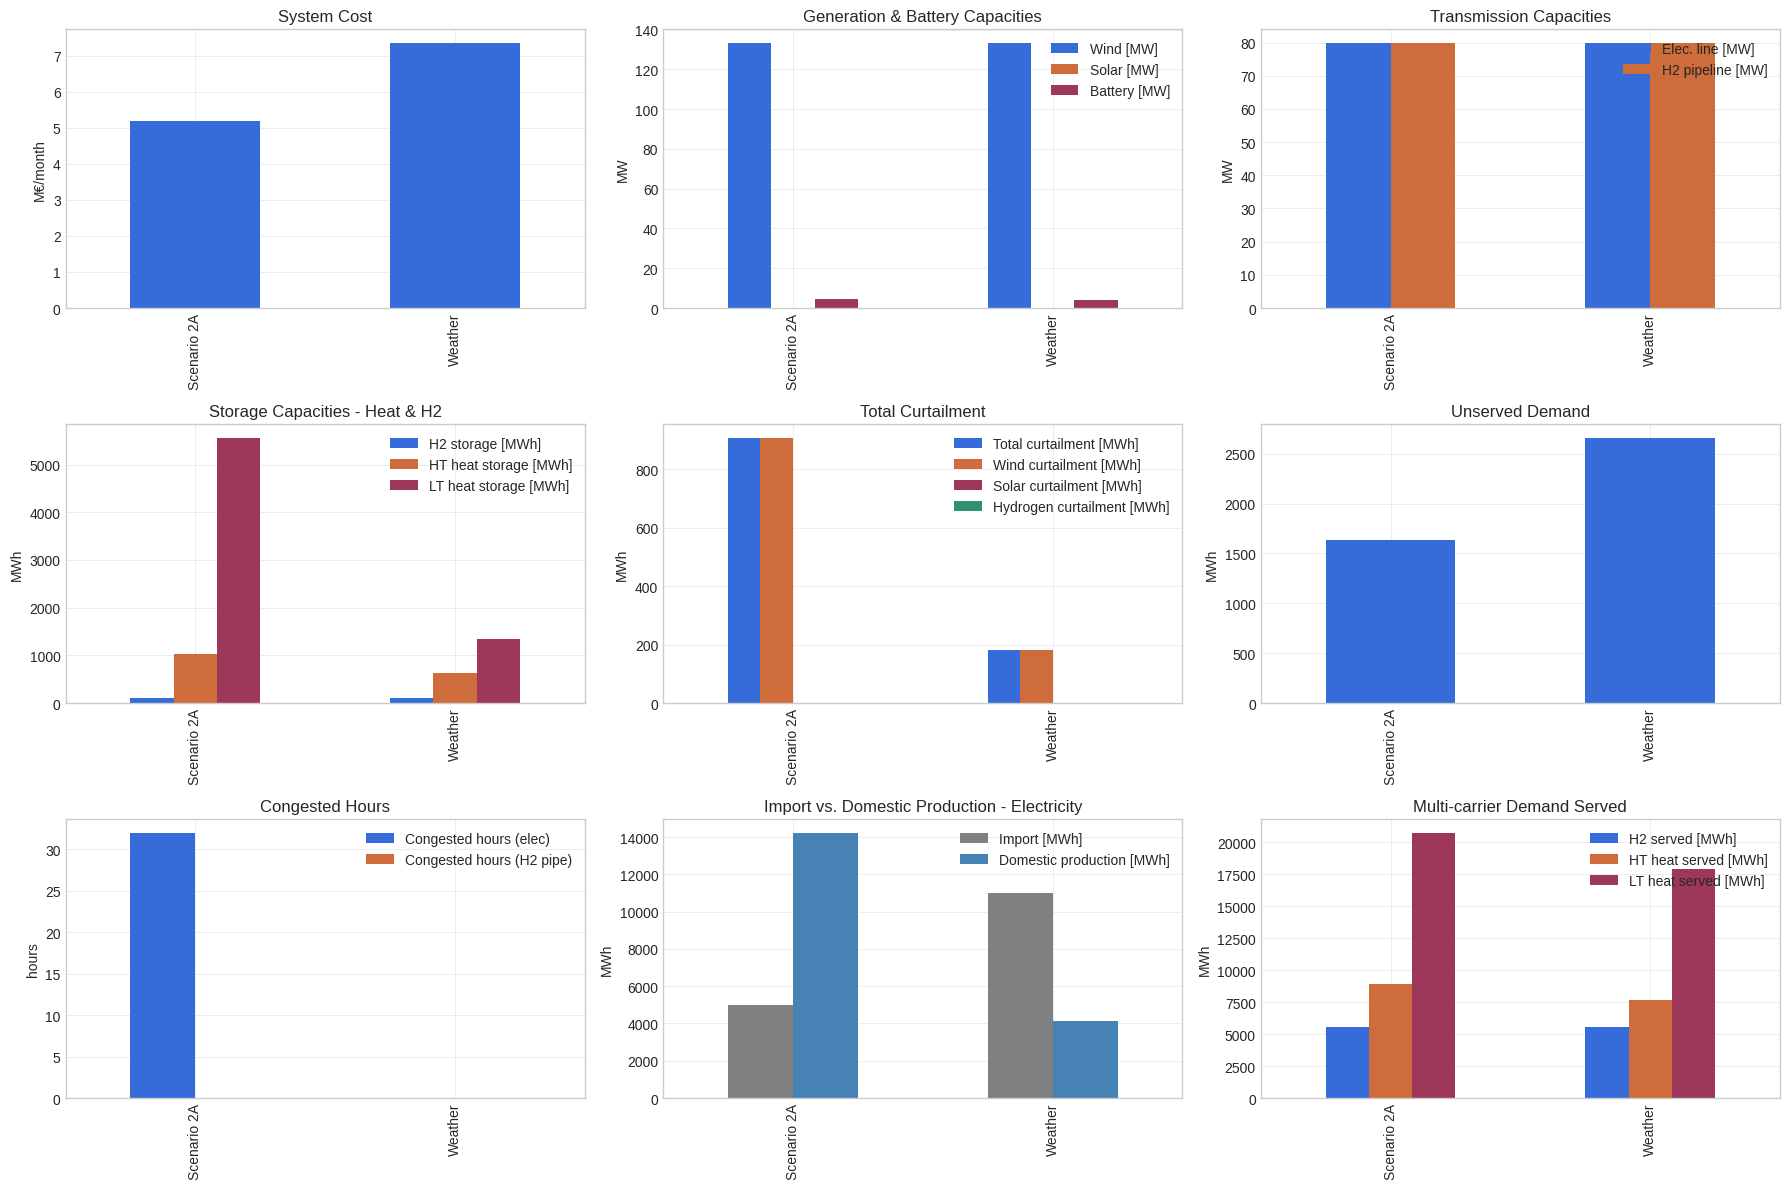

,Total cost [M€/m],Wind [MW],Solar [MW],Battery [MW],Elec. line [MW],H2 pipeline [MW],H2 storage [MWh],HT heat storage [MWh],LT heat storage [MWh],Wind curtailment [MWh],Solar curtailment [MWh],Hydrogen curtailment [MWh],Total curtailment [MWh],Congested hours (elec),Congested hours (H2 pipe),Import [MWh],Domestic production [MWh],Domestic share [%],H2 served [MWh],HT heat served [MWh],LT heat served [MWh],Unserved elec [MWh],Unserved H2 [MWh],Unserved HT heat [MWh],Unserved LT heat [MWh],Total unserved [MWh]
Scenario 2A,5.19,133.41,0.00,4.43,80.00,80.00,100.00,1029.07,5565.85,908.27,0.00,0.00,908.27,32.00,0.00,4976.80,14242.40,0.30,5562.31,8891.00,20745.67,0.48,0.00,1636.83,0.00,1637.30
Weather,7.36,133.00,-0.00,4.00,80.00,80.00,100.00,625.89,1349.10,180.52,0.00,0.00,180.52,0.00,0.00,11002.79,4134.58,0.10,5518.94,7666.84,17889.29,0.00,385.89,2276.27,0.00,2662.16


In [422]:
# Extract KPIs from each network
def extract_kpis(n, label):

#Capacities
    opt_wind       = n.generators.p_nom_opt.get("wind_zone1", 0)
    opt_solar      = n.generators.p_nom_opt.get("solar_zone1", 0)
    opt_hydrogen   = n.generators.p_nom_opt.get("h2_zone3", 0)
    opt_batt       = n.storage_units.p_nom_opt.sum()
    opt_line       = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))
    opt_pipeline   = n.links.p_nom_opt.get("zone3-zone2", n.links.p_nom.get("zone3-zone2", 0))
    opt_h2_store   = n.stores.e_nom_opt.get("h2_storage_zone3", 0)
    opt_ht_store   = n.stores.e_nom_opt.get("heat_high_storage", 0)
    opt_lt_store   = n.stores.e_nom_opt.get("heat_low_storage",  0)

# Loads
    import_mwh    = n.generators_t.p.get("import",        pd.Series(0, dtype=float)).sum()
    unserved_mwh = sum(
        n.generators_t.p.get(name, pd.Series(0, dtype=float)).sum()
        for name in ["load shedding", "loadshed_hydrogen", "loadshed_heat_high", "loadshed_heat_low"]
)

    #  Curtailment
    opt_wind_mw   = n.generators.p_nom_opt["wind_zone1"]  * n.generators_t.p_max_pu["wind_zone1"]
    opt_solar_mw  = n.generators.p_nom_opt["solar_zone1"] * n.generators_t.p_max_pu["solar_zone1"]
    opt_hydrogen_mw = n.generators.p_nom_opt["h2_zone3"] * n.generators_t.p_max_pu["h2_zone3"]

    gen_wind      = n.generators_t.p["wind_zone1"]
    gen_solar     = n.generators_t.p["solar_zone1"]
    gen_hydrogen  = n.generators_t.p["h2_zone3"]
    curtailment_wind  = (opt_wind_mw  - gen_wind ).clip(lower=0).sum()
    curtailment_solar = (opt_solar_mw - gen_solar).clip(lower=0).sum()
    curtailment_hydrogen = (opt_hydrogen_mw - gen_hydrogen).clip(lower=0).sum()
    total_curtailment = curtailment_wind + curtailment_solar + curtailment_hydrogen

    # Energy security
    domestic_production = (gen_wind + gen_solar).sum()
    total_load          = n.loads_t.p.sum().sum()
    domestic_share      = domestic_production / total_load if total_load > 0 else 0

    # H2 & heat served ─────────────────────────────
    h2_served = n.loads_t.p["hydrogen_demand"].sum()
    ht_served  = n.loads_t.p["heat_high_demand"].sum()
    lt_served  = n.loads_t.p["heat_low_demand"].sum()

    # ── Congestion (electricity line) ─────────────────
    if "zone1-zone2" in n.links_t.p0.columns:
        cap = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))
        congested_hours = int((n.links_t.p0["zone1-zone2"].abs() / cap > 0.99).sum()) if cap > 0 else 0
    else:
        congested_hours = 0

    # ── Congestion (H2 pipeline) ──────────────────────
    if "zone3-zone2" in n.links_t.p0.columns:
        cap_pipe = n.links.p_nom_opt.get("zone3-zone2", n.links.p_nom.get("zone3-zone2", 0))
        congested_hours_pipe = int((n.links_t.p0["zone3-zone2"].abs() / cap_pipe > 0.99).sum()) if cap_pipe > 0 else 0
    else:
        congested_hours_pipe = 0

    # ── Cost ──────────────────────────────────────────
    cost_df    = build_cost_df(n, **cost_params)
    total_cost = cost_df["CAPEX"].sum() + cost_df["OPEX"].sum()

    return {
        "Total cost [M€/m]":          total_cost,
        "Wind [MW]":                   opt_wind,
        "Solar [MW]":                  opt_solar,
        "Battery [MW]":                opt_batt,
        "Elec. line [MW]":             opt_line,
        "H2 pipeline [MW]":            opt_pipeline,
        "H2 storage [MWh]":            opt_h2_store,
        "HT heat storage [MWh]":       opt_ht_store,
        "LT heat storage [MWh]":       opt_lt_store,
        "Wind curtailment [MWh]":      curtailment_wind,
        "Solar curtailment [MWh]":     curtailment_solar,
        "Hydrogen curtailment [MWh]": curtailment_hydrogen,
        "Total curtailment [MWh]":     total_curtailment,
        "Congested hours (elec)":      congested_hours,
        "Congested hours (H2 pipe)":   congested_hours_pipe,
        "Import [MWh]":                import_mwh,
        "Domestic production [MWh]":   domestic_production,
        "Domestic share [%]":          domestic_share,
        "H2 served [MWh]":             h2_served,
        "HT heat served [MWh]":        ht_served,
        "LT heat served [MWh]":        lt_served,
        "Unserved elec [MWh]":   n.generators_t.p.get("load shedding",      pd.Series(0, dtype=float)).sum(),
        "Unserved H2 [MWh]":     n.generators_t.p.get("loadshed_hydrogen",   pd.Series(0, dtype=float)).sum(),
        "Unserved HT heat [MWh]":n.generators_t.p.get("loadshed_heat_high",  pd.Series(0, dtype=float)).sum(),
        "Unserved LT heat [MWh]":n.generators_t.p.get("loadshed_heat_low",   pd.Series(0, dtype=float)).sum(),
        "Total unserved [MWh]":  unserved_mwh,
    }

kpis = pd.DataFrame(
    {label: extract_kpis(n, label) for label, n in networks.items()}
)

# ── 3. Side-by-side bar charts ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

kpis.loc[["Total cost [M€/m]"]].T.plot(kind="bar", ax=axes[0], legend=False)
axes[0].set_title("System Cost"); axes[0].set_ylabel("M€/month")

kpis.loc[["Wind [MW]", "Solar [MW]", "Battery [MW]"]].T.plot(kind="bar", ax=axes[1])
axes[1].set_title("Generation & Battery Capacities"); axes[1].set_ylabel("MW")

kpis.loc[["Elec. line [MW]", "H2 pipeline [MW]"]].T.plot(kind="bar", ax=axes[2])
axes[2].set_title("Transmission Capacities"); axes[2].set_ylabel("MW")

kpis.loc[["H2 storage [MWh]", "HT heat storage [MWh]", "LT heat storage [MWh]"]].T.plot(kind="bar", ax=axes[3])
axes[3].set_title("Storage Capacities - Heat & H2"); axes[3].set_ylabel("MWh")

kpis.loc[["Total curtailment [MWh]","Wind curtailment [MWh]","Solar curtailment [MWh]","Hydrogen curtailment [MWh]"  ]].T.plot(kind="bar", ax=axes[4])
axes[4].set_title("Total Curtailment"); axes[4].set_ylabel("MWh")

kpis.loc[["Total unserved [MWh]"]].T.plot(kind="bar", ax=axes[5], legend=False)
axes[5].set_title("Unserved Demand"); axes[5].set_ylabel("MWh")

kpis.loc[["Congested hours (elec)", "Congested hours (H2 pipe)"]].T.plot(kind="bar", ax=axes[6])
axes[6].set_title("Congested Hours"); axes[6].set_ylabel("hours")

kpis.loc[["Import [MWh]", "Domestic production [MWh]"]].T.plot(kind="bar", ax=axes[7], color=["grey", "steelblue"])
axes[7].set_title("Import vs. Domestic Production - Electricity"); axes[7].set_ylabel("MWh")

kpis.loc[["H2 served [MWh]", "HT heat served [MWh]", "LT heat served [MWh]"]].T.plot(kind="bar", ax=axes[8])
axes[8].set_title("Multi-carrier Demand Served"); axes[8].set_ylabel("MWh")

plt.tight_layout(); plt.show()

display(
    kpis.T.style
        .format("{:.2f}")
        .background_gradient(cmap="RdYlGn_r", axis=0)
        .set_caption("KPI Comparison Across Scenarios")
)

The figures and tables above represent an overview of the KPIs across our scenarios.

### Unserved Demand

Unserved demand was a serious issue in Part 2. As noted, our production/demand balance for hydrogen results in a deficit. We see it manifested here in the massive high heat load shedding - over 1600 MWh over the course of the month.

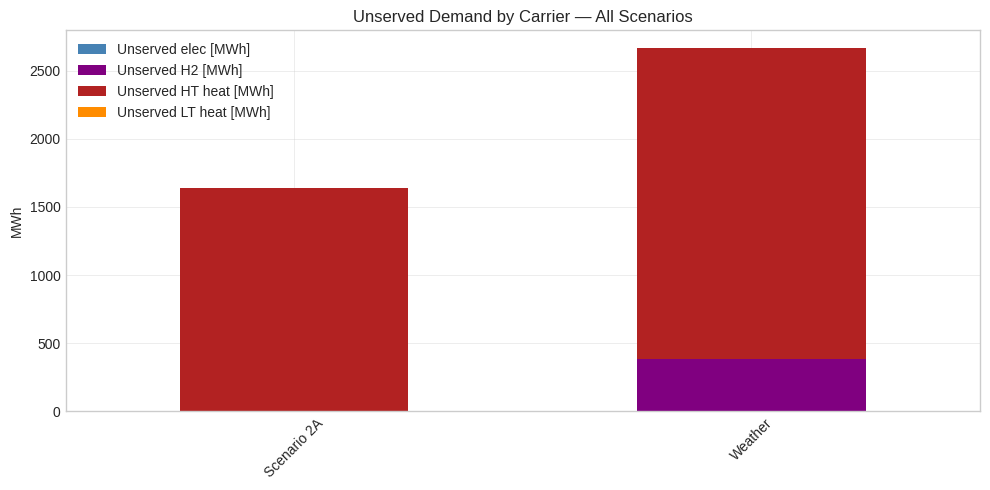

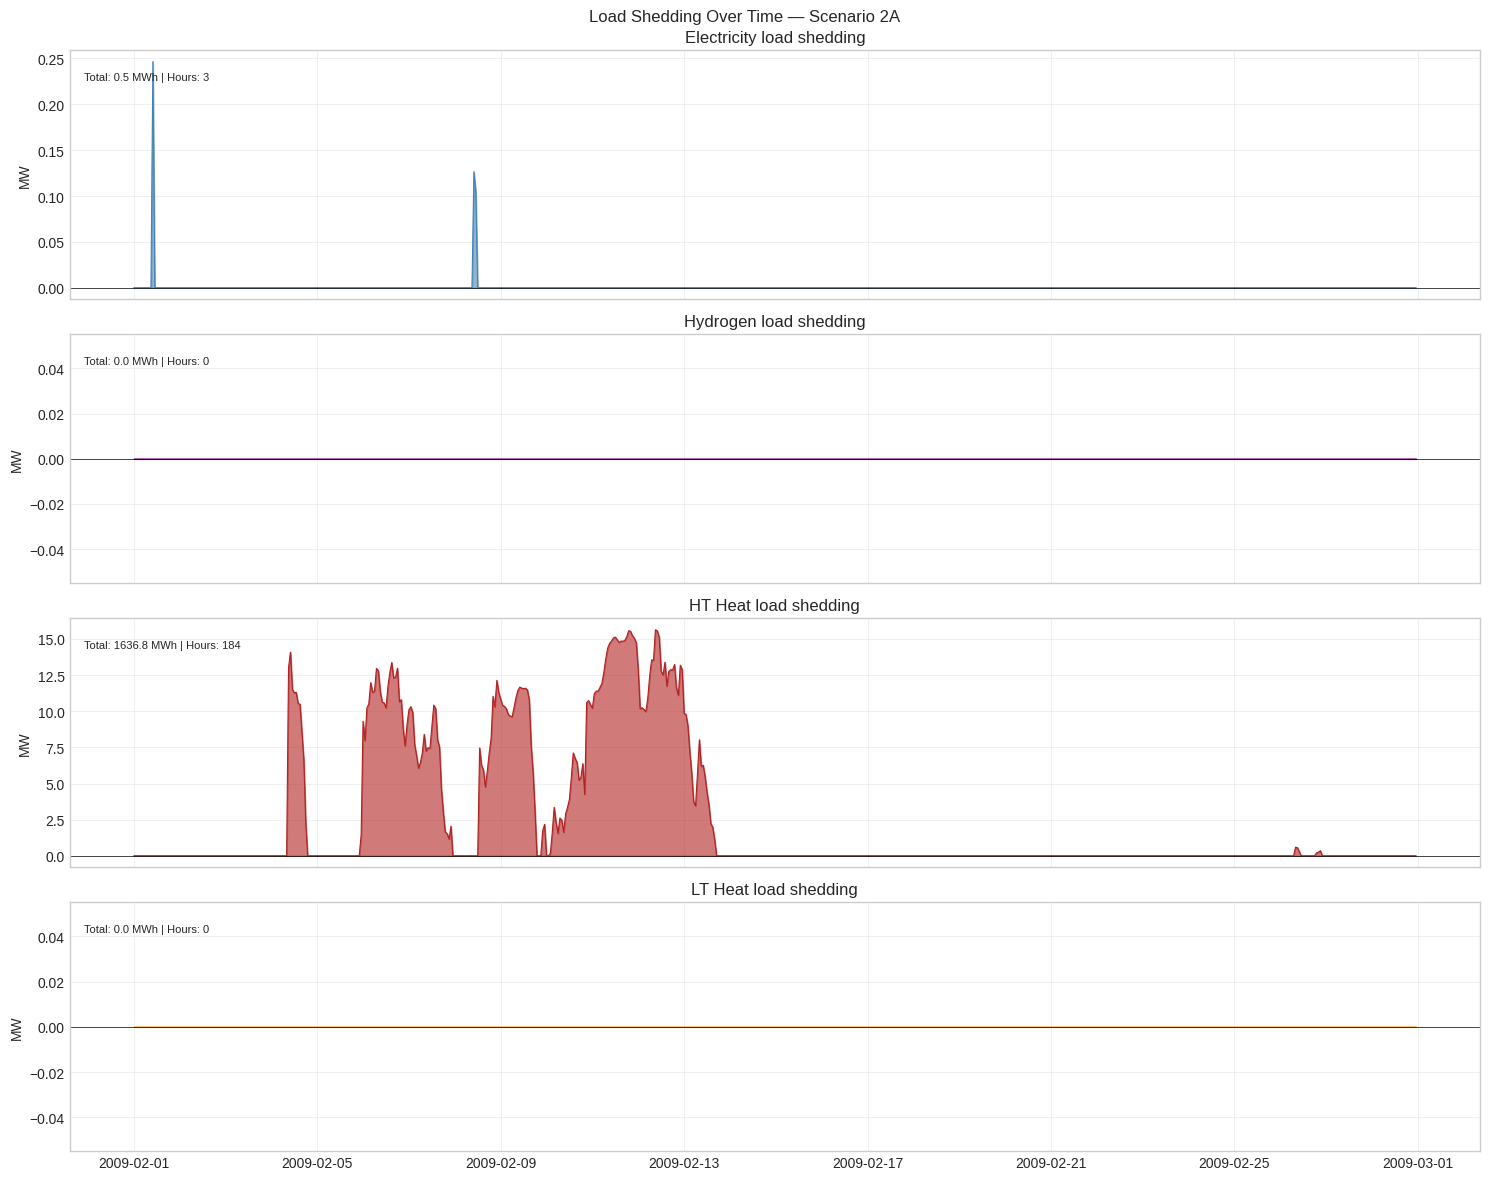

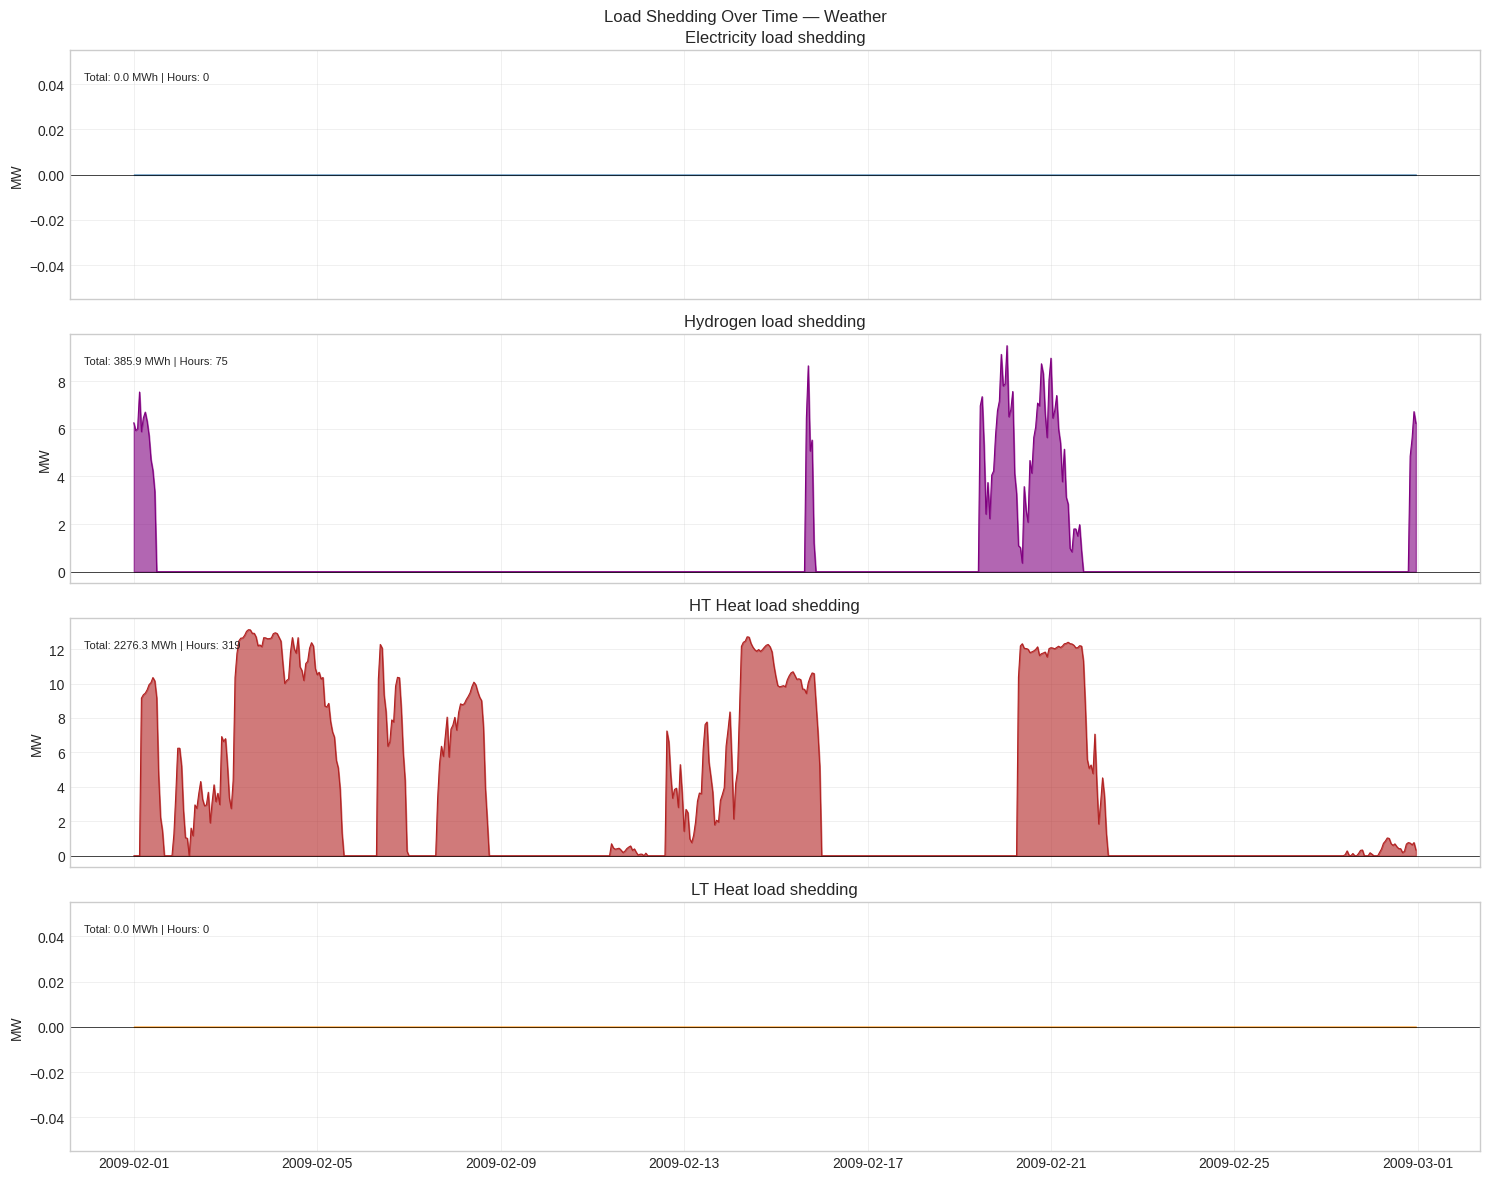

In [411]:
# 1. Stacked bar: unserved by carrier across scenarios
fig, ax = plt.subplots(figsize=(10, 5))

unserved_df = kpis.loc[[
    "Unserved elec [MWh]",
    "Unserved H2 [MWh]",
    "Unserved HT heat [MWh]",
    "Unserved LT heat [MWh]",
]].T

unserved_df.plot(
    kind="bar", stacked=True, ax=ax,
    color=["steelblue", "purple", "firebrick", "darkorange"]
)
ax.set_title("Unserved Demand by Carrier — All Scenarios")
ax.set_ylabel("MWh")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 2. Time series: all carriers for each scenario ───────────────────────────
shed_components = {
    "Electricity":  "load shedding",
    "Hydrogen":     "loadshed_hydrogen",
    "HT Heat":      "loadshed_heat_high",
    "LT Heat":      "loadshed_heat_low",
}
colors = {
    "Electricity": "steelblue",
    "Hydrogen":    "purple",
    "HT Heat":     "firebrick",
    "LT Heat":     "darkorange",
}

for label, net in networks.items():
    fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

    for ax, (carrier, gen_name) in zip(axes, shed_components.items()):
        series = net.generators_t.p.get(gen_name, pd.Series(0, dtype=float))
        if isinstance(series, pd.DataFrame):
            series = series.squeeze()

        ax.fill_between(series.index, series.values,
                        color=colors[carrier], alpha=0.6)
        ax.plot(series.index, series.values,
                color=colors[carrier], linewidth=0.8)
        ax.set_ylabel("MW")
        ax.set_title(f"{carrier} load shedding")
        ax.axhline(0, color="black", linewidth=0.5)
        ax.grid(True, alpha=0.4)

        total = series.sum()
        hours = (series > 0).sum()
        ax.annotate(f"Total: {total:.1f} MWh | Hours: {hours}",
                    xy=(0.01, 0.88), xycoords="axes fraction", fontsize=8)

    plt.suptitle(f"Load Shedding Over Time — {label}", fontsize=12)
    plt.tight_layout()
    plt.show()

# 3. Summary stats table
summary_rows = []
for label, net in networks.items():
    for carrier, gen_name in shed_components.items():
        series = net.generators_t.p.get(gen_name, pd.Series(0, dtype=float))
        if isinstance(series, pd.DataFrame):
            series = series.squeeze()
        summary_rows.append({
            "Scenario": label,
            "Carrier":  carrier,
            "Total [MWh]": round(series.sum(), 1),
            "Hours":        int((series > 0).sum()),
            "Peak [MW]":   round(series.max(), 1),
        })

summary_df = pd.DataFrame(summary_rows).set_index(["Scenario", "Carrier"])
display(
    summary_df.style
        .format("{:.1f}", subset=["Total [MWh]", "Peak [MW]"])
        .background_gradient(cmap="Reds", subset=["Total [MWh]"])
        .set_caption("Load Shedding Summary by Scenario and Carrier")
)

In [412]:
penalty_rows = []
for label, net in networks.items():
    for carrier, gen_name in {
        "Electricity": "load shedding",
        "HT Heat":     "loadshed_heat_high",
        "LT Heat":     "loadshed_heat_low",
        "Hydrogen":    "loadshed_hydrogen",
    }.items():
        unserved = net.generators_t.p.get(gen_name, pd.Series(0, dtype=float)).sum()
        penalty_rows.append({
            "Scenario": label,
            "Carrier":  carrier,
            "Unserved [MWh]":   round(unserved, 1),
            "Penalty [€/MWh]":  Operational_cost_lost_load_penalty,
            "Total penalty [€]": round(unserved * Operational_cost_lost_load_penalty, 0),
        })

penalty_df = pd.DataFrame(penalty_rows).set_index(["Scenario", "Carrier"])

display(
    penalty_df.style
        .format({
            "Unserved [MWh]":    "{:.1f}",
            "Penalty [€/MWh]":   "{:.0f}",
            "Total penalty [€]": "{:,.0f}",
        })
        .background_gradient(cmap="Reds", subset=["Total penalty [€]"])
        .set_caption("Load Shedding Penalties by Scenario and Carrier")
)

# Total per scenario
totals = penalty_df.groupby("Scenario")["Total penalty [€]"].sum()
print("\nTotal penalties by scenario:")
print(totals.apply(lambda x: f"€{x:,.0f}").to_string())


Total penalties by scenario:
Scenario
Scenario 2A    €2,455,954
Weather        €3,993,236


The table above shows the price paid for this lack of production/demand balance for hydrogen. Almost half our total system cost is going to load shedding penalties for high heat.

### Conversion and Transport Losses

The conversion and transport losses are plotted below. Electricity cable losses are not insignificant but our system's ability to store surplus wind makes its affect negligible. Most notable is the conversion loss associated with the H2 boiler - 4000 MWh in our scenarios. Coupled with our lack of a production cushion the 65% efficiency is a significant contributor to our struggles to cover demand and the resulting load shedding that must occur.

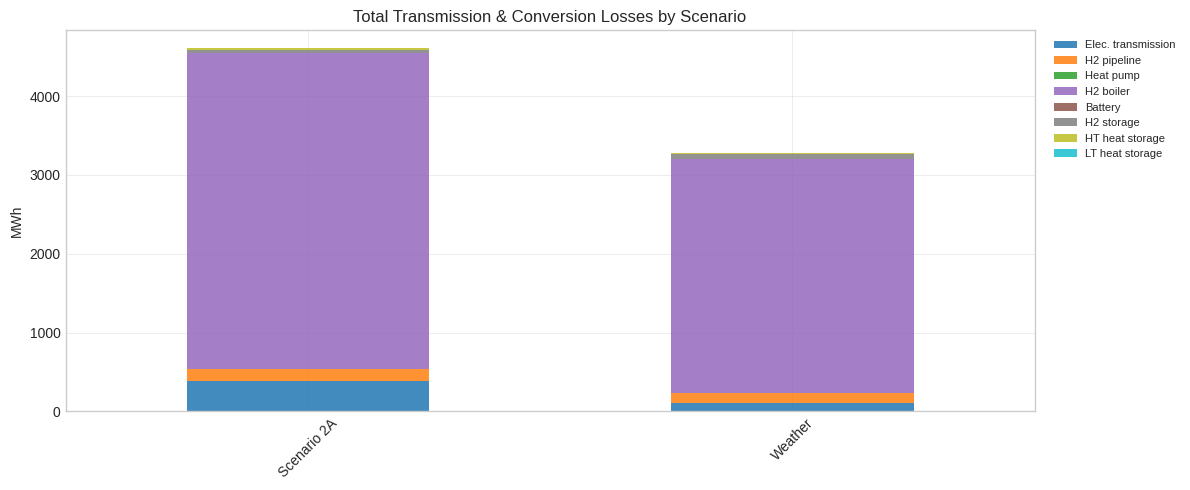

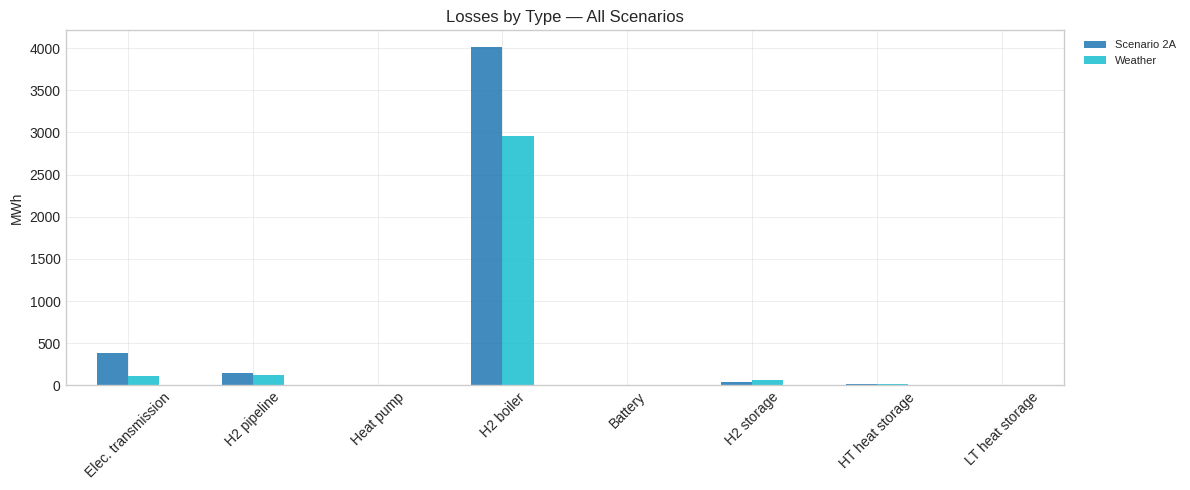

,Elec. transmission,H2 pipeline,Heat pump,H2 boiler,Battery,H2 storage,HT heat storage,LT heat storage
Scenario 2A,382.2,152.9,0.0,4009.6,0.0,43.0,15.0,0.0
Weather,111.1,122.2,0.0,2962.2,0.0,64.5,16.0,0.0


In [413]:
def get_losses(net):
    losses = {}

    # ── Transmission losses ───────────────────────────────────────
    # Electricity cable zone1 → zone2
    if "zone1-zone2" in net.links_t.p0.columns:
        p0 = net.links_t.p0["zone1-zone2"]
        p1 = net.links_t.p1["zone1-zone2"].abs()
        losses["Elec. transmission"] = (p0 - p1).clip(lower=0).sum()

    # H2 pipeline zone3 → zone2
    if "zone3-zone2" in net.links_t.p0.columns:
        p0 = net.links_t.p0["zone3-zone2"]
        p1 = net.links_t.p1["zone3-zone2"].abs()
        losses["H2 pipeline"] = (p0 - p1).clip(lower=0).sum()

    # ── Conversion losses ─────────────────────────────────────────
    # Heat pump (electricity → low heat)
    if "heatpump_zone2" in net.links_t.p0.columns:
        p0 = net.links_t.p0["heatpump_zone2"]
        p1 = net.links_t.p1["heatpump_zone2"].abs()
        losses["Heat pump"] = (p0 - p1).clip(lower=0).sum()

    # H2 boiler (hydrogen → high heat)
    if "h2_boiler_zone2" in net.links_t.p0.columns:
        p0 = net.links_t.p0["h2_boiler_zone2"]
        p1 = net.links_t.p1["h2_boiler_zone2"].abs()
        losses["H2 boiler"] = (p0 - p1).clip(lower=0).sum()

    # ── Storage losses ────────────────────────────────────────────
    # Battery (round-trip)
    if "battery storage zone 1" in net.storage_units_t.p_store.columns:
        charged    = net.storage_units_t.p_store["battery storage zone 1"].sum()
        discharged = net.storage_units_t.p_dispatch["battery storage zone 1"].sum()
        losses["Battery"] = (charged - discharged).clip(0)

    # H2 storage charge link
    if "h2_charge_zone3" in net.links_t.p0.columns:
        p0 = net.links_t.p0["h2_charge_zone3"]
        p1 = net.links_t.p1["h2_charge_zone3"].abs()
        losses["H2 storage"] = (p0 - p1).clip(lower=0).sum()

    # Heat storage links
    for name, key in [("HT heat storage", "heat_high_charge"),
                      ("LT heat storage", "heat_low_charge")]:
        if key in net.links_t.p0.columns:
            p0 = net.links_t.p0[key]
            p1 = net.links_t.p1[key].abs()
            losses[name] = (p0 - p1).clip(lower=0).sum()

    return losses


# ── Build losses DataFrame ────────────────────────────────────────
losses_df = pd.DataFrame(
    {label: get_losses(net) for label, net in networks.items()}
).T.fillna(0)

# ── Plot 1: Stacked bar ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
losses_df.plot(
    kind="bar", stacked=True, ax=ax,
    colormap="tab10", alpha=0.85
)
ax.set_title("Total Transmission & Conversion Losses by Scenario")
ax.set_ylabel("MWh")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 2: Grouped bar by loss type ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
losses_df.T.plot(
    kind="bar", ax=ax,
    colormap="tab10", alpha=0.85
)
ax.set_title("Losses by Type — All Scenarios")
ax.set_ylabel("MWh")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────
display(
    losses_df.style
        .format("{:.1f}")
        .background_gradient(cmap="Oranges", axis=0)
        .set_caption("Transmission & Conversion Losses by Scenario (MWh)")
)

### System Cost Comparision

In the figures below, we can see different design choices reflected in the overall system costs.

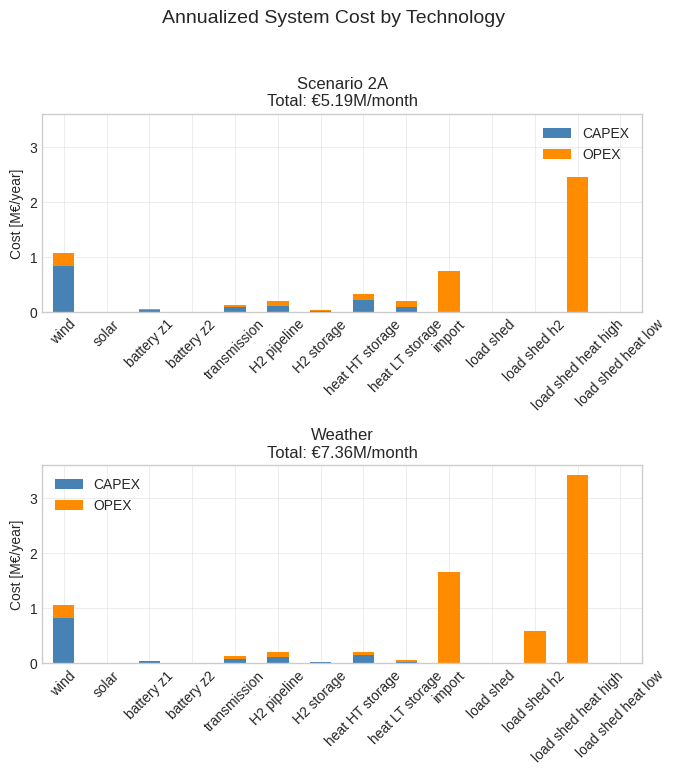

In [414]:
import math

n_plots = len(networks)
n_rows = 3
n_cols = math.ceil(n_plots / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 10), sharey=True)

axes = axes.flatten()  # makes iteration easy

for ax, (label, n) in zip(axes, networks.items()):
    cost_df = build_cost_df(n, **cost_params)
    total   = cost_df["CAPEX"].sum() + cost_df["OPEX"].sum()

    cost_df[["CAPEX", "OPEX"]].plot(
        kind="bar", stacked=True, ax=ax,
        color=["steelblue", "darkorange"]
    )
    ax.set_title(f"{label}\nTotal: €{total:.2f}M/month")
    ax.set_ylabel("Cost [M€/year]")
    ax.tick_params(axis="x", rotation=45)

# hide any unused subplots
for ax in axes[len(networks):]:
    ax.set_visible(False)

plt.suptitle("Annualized System Cost by Technology", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Transmission / Utilization of the Line
A goal of our system is to avoid line and pipeline congestion.

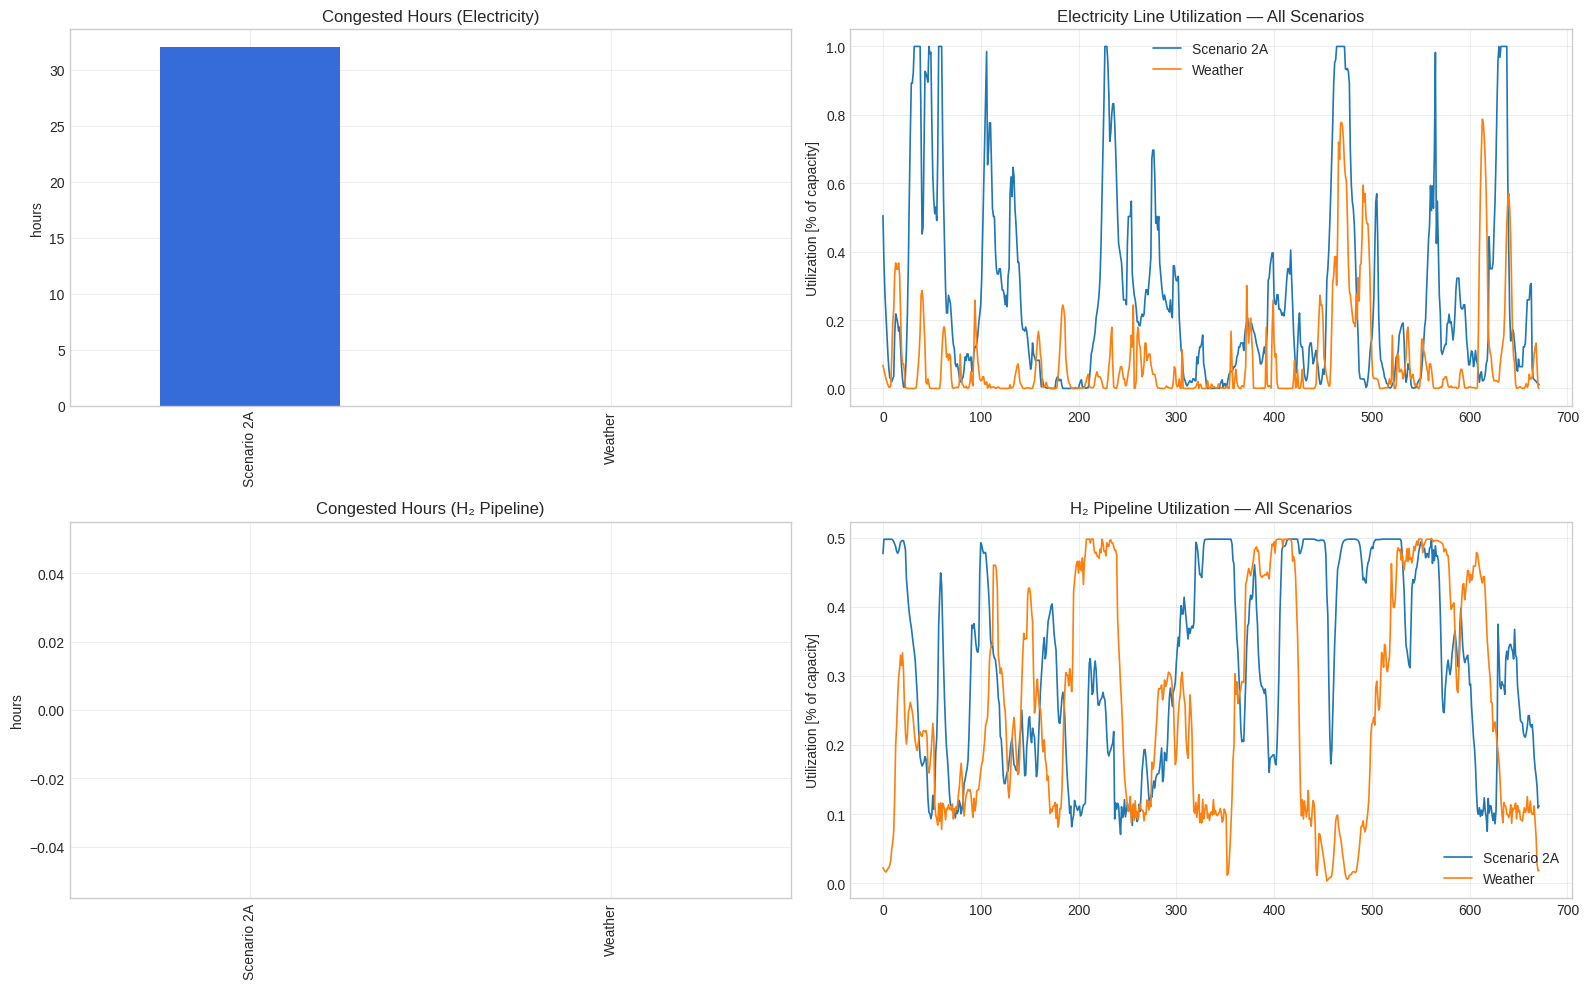

In [415]:
def plot_line_utilization_combined(networks, ax):
    valid = {label: n for label, n in networks.items()
             if "zone1-zone2" in n.links_t.p0.columns}
    if not valid:
        print("No networks have link flow data.")
        return

    colors = plt.cm.tab10.colors

    for (label, n), color in zip(valid.items(), colors):
        opt_line_capacity = n.links.p_nom_opt.get("zone1-zone2",
                            n.links.p_nom.get("zone1-zone2", 0))
        if opt_line_capacity == 0:
            continue
        utilization = n.links_t.p0["zone1-zone2"].abs() / opt_line_capacity
        ax.plot(utilization.values, label=label, color=color, linewidth=1.2)

    ax.set_ylabel("Utilization [% of capacity]")
    ax.set_title("Electricity Line Utilization — All Scenarios")
    ax.legend()


def plot_pipeline_utilization_combined(networks, ax):
    valid = {label: n for label, n in networks.items()
             if "zone3-zone2" in n.links_t.p0.columns}
    if not valid:
        print("No networks have pipeline flow data.")
        return

    colors = plt.cm.tab10.colors

    for (label, n), color in zip(valid.items(), colors):
        opt_pipe_capacity = n.links.p_nom_opt.get("zone3-zone2",
                            n.links.p_nom.get("zone3-zone2", 0))
        if opt_pipe_capacity == 0:
            continue
        utilization = n.links_t.p0["zone3-zone2"].abs() / opt_pipe_capacity
        ax.plot(utilization.values, label=label, color=color, linewidth=1.2)

    ax.set_ylabel("Utilization [% of capacity]")
    ax.set_title("H₂ Pipeline Utilization — All Scenarios")
    ax.legend()


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

kpis.loc[["Congested hours (elec)"]].T \
    .plot(kind="bar", ax=axes[0, 0], legend=False)
axes[0, 0].set_title("Congested Hours (Electricity)")
axes[0, 0].set_ylabel("hours")

plot_line_utilization_combined(networks, ax=axes[0, 1])

kpis.loc[["Congested hours (H2 pipe)"]].T \
    .plot(kind="bar", ax=axes[1, 0], legend=False)
axes[1, 0].set_title("Congested Hours (H₂ Pipeline)")
axes[1, 0].set_ylabel("hours")

plot_pipeline_utilization_combined(networks, ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [416]:
util_rows = []

for label, net in networks.items():
    row = {"Scenario": label}

    # ── Electricity cable ─────────────────────────────────────────
    if "zone1-zone2" in net.links_t.p0.columns:
        cap = net.links.p_nom_opt.get("zone1-zone2", net.links.p_nom.get("zone1-zone2", 0))
        if cap > 0:
            flow = net.links_t.p0["zone1-zone2"].abs()
            util = flow / cap
            row["Elec. capacity [MW]"]      = round(cap, 1)
            row["Elec. avg utilization [%]"] = round(util.mean() * 100, 1)
            row["Elec. max utilization [%]"] = round(util.max() * 100, 1)
            row["Elec. congested hours"]     = int((util > 0.99).sum())
        else:
            row["Elec. capacity [MW]"]       = 0
            row["Elec. avg utilization [%]"] = 0
            row["Elec. max utilization [%]"] = 0
            row["Elec. congested hours"]     = 0
    else:
        row["Elec. capacity [MW]"]       = 0
        row["Elec. avg utilization [%]"] = 0
        row["Elec. max utilization [%]"] = 0
        row["Elec. congested hours"]     = 0

    # ── H2 pipeline ───────────────────────────────────────────────
    if "zone3-zone2" in net.links_t.p0.columns:
        cap = net.links.p_nom_opt.get("zone3-zone2", net.links.p_nom.get("zone3-zone2", 0))
        if cap > 0:
            flow = net.links_t.p0["zone3-zone2"].abs()
            util = flow / cap
            row["H2 pipe capacity [MW]"]      = round(cap, 1)
            row["H2 pipe avg utilization [%]"] = round(util.mean() * 100, 1)
            row["H2 pipe max utilization [%]"] = round(util.max() * 100, 1)
            row["H2 pipe congested hours"]     = int((util > 0.99).sum())
        else:
            row["H2 pipe capacity [MW]"]       = 0
            row["H2 pipe avg utilization [%]"] = 0
            row["H2 pipe max utilization [%]"] = 0
            row["H2 pipe congested hours"]     = 0
    else:
        row["H2 pipe capacity [MW]"]       = 0
        row["H2 pipe avg utilization [%]"] = 0
        row["H2 pipe max utilization [%]"] = 0
        row["H2 pipe congested hours"]     = 0

    util_rows.append(row)

util_df = pd.DataFrame(util_rows).set_index("Scenario")

display(
    util_df.style
        .format({
            "Elec. capacity [MW]":        "{:.1f}",
            "Elec. avg utilization [%]":  "{:.1f}",
            "Elec. max utilization [%]":  "{:.1f}",
            "Elec. congested hours":      "{:.0f}",
            "H2 pipe capacity [MW]":      "{:.1f}",
            "H2 pipe avg utilization [%]":"{:.1f}",
            "H2 pipe max utilization [%]":"{:.1f}",
            "H2 pipe congested hours":    "{:.0f}",
        })
        .background_gradient(cmap="RdYlGn_r",
                             subset=["Elec. avg utilization [%]",
                                     "H2 pipe avg utilization [%]",
                                     "Elec. congested hours",
                                     "H2 pipe congested hours"])
        .set_caption("Transmission Utilization & Congestion by Scenario")
)

,Elec. capacity [MW],Elec. avg utilization [%],Elec. max utilization [%],Elec. congested hours,H2 pipe capacity [MW],H2 pipe avg utilization [%],H2 pipe max utilization [%],H2 pipe congested hours
Scenario,,,,,,,,
Scenario 2A,80.0,26.5,100.0,32,80.0,31.9,49.8,0
Weather,80.0,7.7,78.7,0,80.0,25.5,49.8,0


### Storage

As noted in Part 1, it was originally thought that a battery at Zone 2 could take advantage of "free" transmission, transmitting surplus energy to the battery at a time when cable losses were irrelevant due to the wind and solar surplus. We realized this was an error in the assumption's relative value and that Zone 1 was the superior location because it avoided line congestion. The battery was able to capture surplus renewables while freeing up transmission for use by demand.In the figure below, Scenario B is highlighted - the only scenario to have the max capacity value of 20MW and be located at Zone 2.

/tmp/ipykernel_18596/3667437502.py:60: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


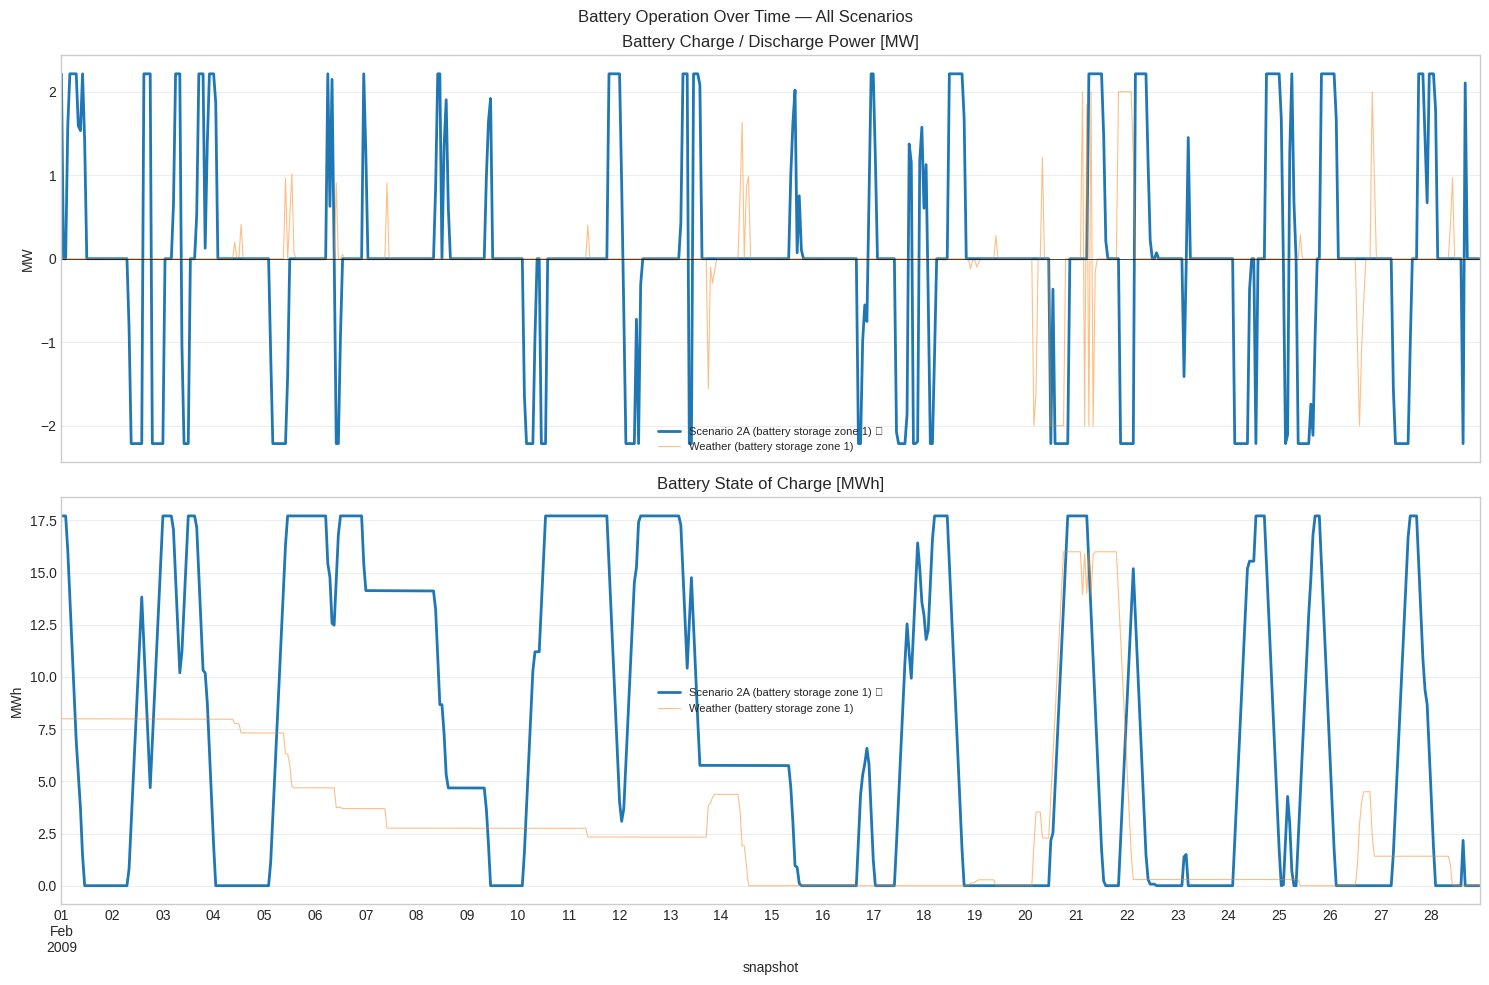

/tmp/ipykernel_18596/3667437502.py:94: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18596/3667437502.py:94: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


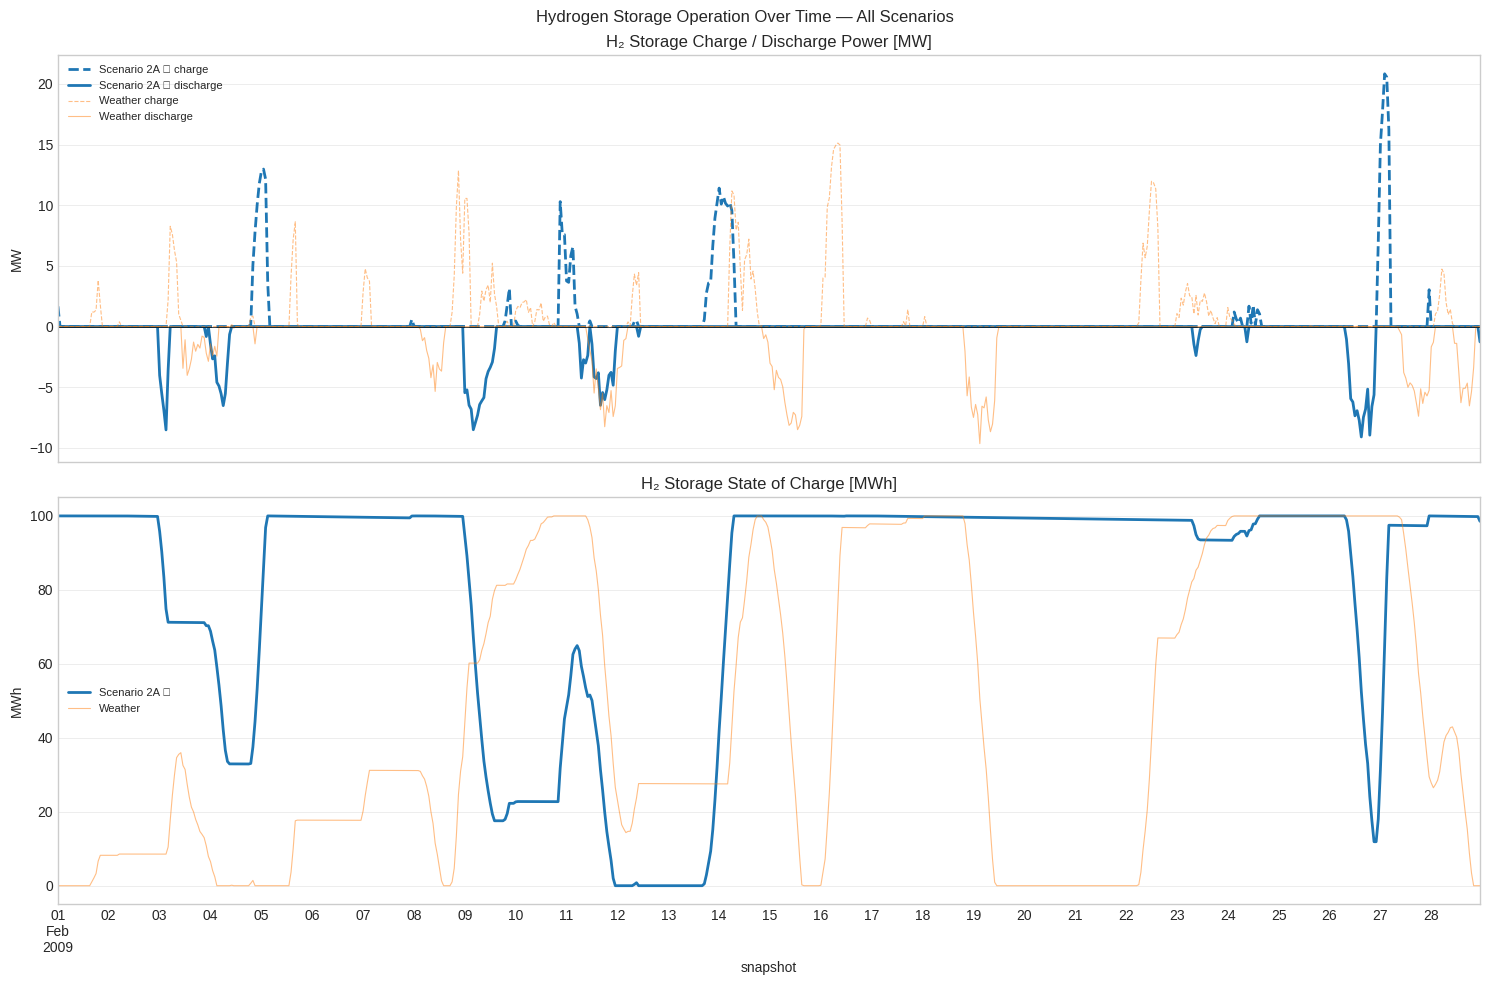

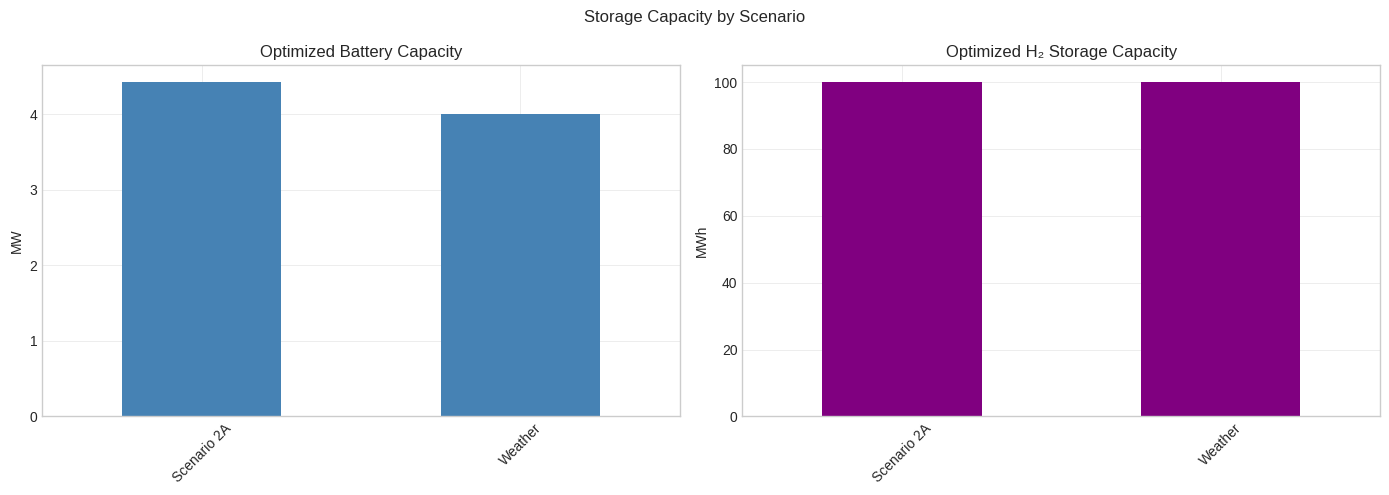

In [417]:
def get_battery_series(net, attr):
    su_t = getattr(net.storage_units_t, attr)
    for name in ["battery storage zone 1", "battery storage zone 2"]:
        if name in su_t.columns:
            return su_t[name], name
    return None, None

def get_max_battery_capacity(net):
    for name in ["battery storage zone 1", "battery storage zone 2"]:
        if name in net.storage_units.p_nom_opt.index:
            return net.storage_units.p_nom_opt[name]
    return 0

def get_h2_storage_series(net, component):
    """Return H2 storage time series — charge flow, discharge flow, or SOC."""
    if component == "charge":
        if "h2_charge_zone3" in net.links_t.p0.columns:
            return net.links_t.p0["h2_charge_zone3"]
    elif component == "discharge":
        if "h2_discharge_zone3" in net.links_t.p0.columns:
            return -net.links_t.p0["h2_discharge_zone3"]
    elif component == "soc":
        if "h2_storage_zone3" in net.stores_t.e.columns:
            return net.stores_t.e["h2_storage_zone3"]
    return None

colors = plt.cm.tab10.colors
max_label = max(networks, key=lambda label: get_max_battery_capacity(networks[label]))
max_h2_label = max(
    networks,
    key=lambda label: networks[label].stores.e_nom_opt.get("h2_storage_zone3", 0)
)

# ── Battery plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for (label, net), color in zip(networks.items(), colors):
    p_series, batt_name = get_battery_series(net, "p")
    soc_series, _       = get_battery_series(net, "state_of_charge")
    if p_series is None:
        continue
    is_max = label == max_label
    lw     = 2.0 if is_max else 0.8
    alpha  = 1.0 if is_max else 0.5
    lbl    = f"{label} ({batt_name}) ★" if is_max else f"{label} ({batt_name})"
    p_series.plot(ax=axes[0], label=lbl, color=color, linewidth=lw, alpha=alpha)
    soc_series.plot(ax=axes[1], label=lbl, color=color, linewidth=lw, alpha=alpha)

axes[0].set_ylabel("MW")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Battery Charge / Discharge Power [MW]")
axes[0].legend(fontsize=8)
axes[0].grid(True)
axes[1].set_ylabel("MWh")
axes[1].set_title("Battery State of Charge [MWh]")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.suptitle("Battery Operation Over Time — All Scenarios")
plt.tight_layout()
plt.show()

# ── H2 storage plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for (label, net), color in zip(networks.items(), colors):
    charge    = get_h2_storage_series(net, "charge")
    discharge = get_h2_storage_series(net, "discharge")
    soc       = get_h2_storage_series(net, "soc")

    if charge is None or soc is None:
        continue

    is_max = label == max_h2_label
    lw     = 2.0 if is_max else 0.8
    alpha  = 1.0 if is_max else 0.5
    lbl    = f"{label} ★" if is_max else label

    charge.plot(ax=axes[0], label=f"{lbl} charge",    color=color, linewidth=lw, alpha=alpha, linestyle="--")
    discharge.plot(ax=axes[0], label=f"{lbl} discharge", color=color, linewidth=lw, alpha=alpha, linestyle="-")
    soc.plot(ax=axes[1], label=lbl, color=color, linewidth=lw, alpha=alpha)

axes[0].set_ylabel("MW")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("H₂ Storage Charge / Discharge Power [MW]")
axes[0].legend(fontsize=8)
axes[0].grid(True)
axes[1].set_ylabel("MWh")
axes[1].set_title("H₂ Storage State of Charge [MWh]")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.suptitle("Hydrogen Storage Operation Over Time — All Scenarios")
plt.tight_layout()
plt.show()

# ── Storage capacity comparison bar chart ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kpis.loc[["Battery [MW]"]].T.plot(kind="bar", ax=axes[0], legend=False, color="steelblue")
axes[0].set_title("Optimized Battery Capacity")
axes[0].set_ylabel("MW")
axes[0].tick_params(axis="x", rotation=45)

kpis.loc[["H2 storage [MWh]"]].T.plot(kind="bar", ax=axes[1], legend=False, color="purple")
axes[1].set_title("Optimized H₂ Storage Capacity")
axes[1].set_ylabel("MWh")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Storage Capacity by Scenario")
plt.tight_layout()
plt.show()

As can be seen in the plots above, we were given the freedom size our battery as we saw fit and the result was the ability to overbuild capacity. However, the same was not true with the H2 storage, capped at 100 MW. With our production shortages, ample storage would be necessary to give our system a chance to handle time balance issues. With the restrictions in place our SOC averaged around 80% and we saw around 400 hours at full across scenarios (see table below).

In [418]:
h2_storage_rows = []

for label, net in networks.items():
    if "h2_storage_zone3" not in net.stores_t.e.columns:
        continue

    soc      = net.stores_t.e["h2_storage_zone3"]
    e_nom    = net.stores.e_nom_opt.get("h2_storage_zone3", 0)

    if e_nom > 0:
        full_hours  = int((soc >= 0.99 * e_nom).sum())
        empty_hours = int((soc <= 0.01 * e_nom).sum())
    else:
        full_hours  = 0
        empty_hours = 0

    h2_storage_rows.append({
        "Scenario":            label,
        "Capacity [MWh]":      round(e_nom, 1),
        "Hours full (≥99%)":   full_hours,
        "Hours empty (≤1%)":   empty_hours,
        "Avg SOC [MWh]":       round(soc.mean(), 1),
        "Avg SOC [%]":         round(soc.mean() / e_nom * 100, 1) if e_nom > 0 else 0,
    })

h2_storage_df = pd.DataFrame(h2_storage_rows).set_index("Scenario")

display(
    h2_storage_df.style
        .format({
            "Capacity [MWh]":    "{:.1f}",
            "Hours full (≥99%)": "{:.0f}",
            "Hours empty (≤1%)": "{:.0f}",
            "Avg SOC [MWh]":     "{:.1f}",
            "Avg SOC [%]":       "{:.1f}",
        })
        .background_gradient(cmap="RdYlGn_r", subset=["Hours full (≥99%)", "Hours empty (≤1%)"])
        .set_caption("H₂ Storage Utilization by Scenario")
)

,Capacity [MWh],Hours full (≥99%),Hours empty (≤1%),Avg SOC [MWh],Avg SOC [%]
Scenario,,,,,
Scenario 2A,100.0,398,43,80.7,80.7
Weather,100.0,130,137,47.0,47.0


### Curtailment
As in Part 1, we also look at curtailment.

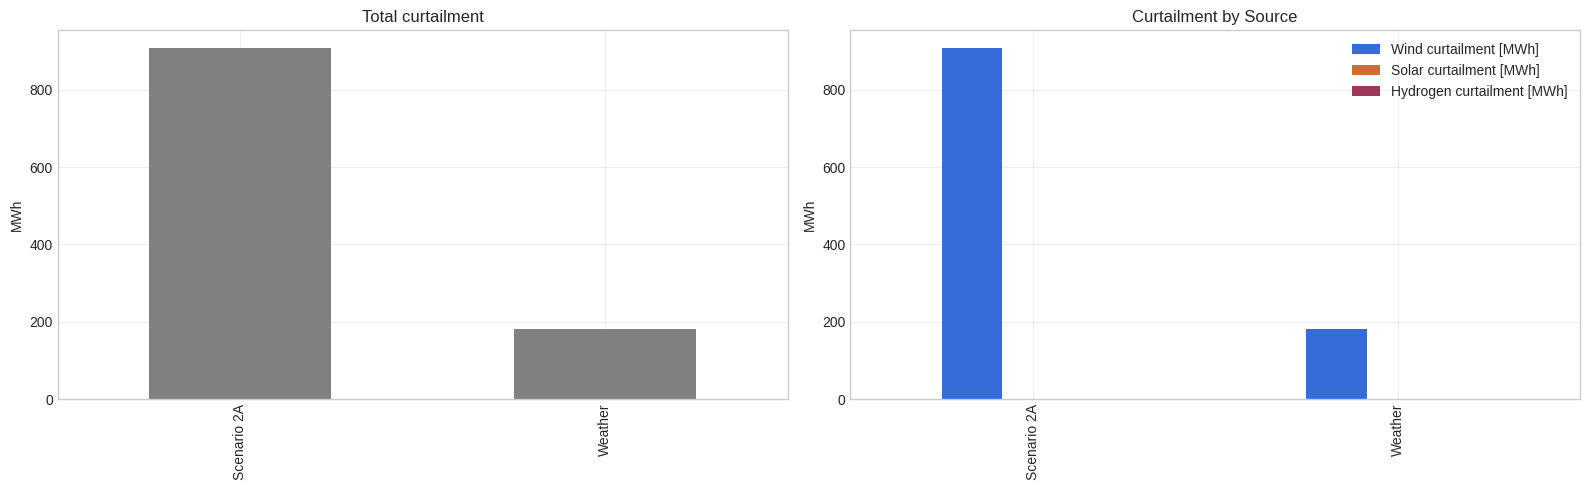

,Wind curtailment [MWh],Solar curtailment [MWh],Hydrogen curtailment [MWh],Total curtailment [MWh]
Scenario 2A,908.3,0.0,0.0,908.3
Weather,180.5,0.0,0.0,180.5


,Wind curtailment [MWh],Solar curtailment [MWh],Hydrogen curtailment [MWh],Total curtailment [MWh]
Scenario 2A,908.3,0.0,0.0,908.3
Weather,180.5,0.0,0.0,180.5


In [419]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

kpis.loc[["Total curtailment [MWh]"]].T \
    .plot(kind="bar", ax=axes[0], legend=False, color="grey")
axes[0].set_title("Total curtailment")
axes[0].set_ylabel("MWh")

kpis.loc[["Wind curtailment [MWh]", "Solar curtailment [MWh]", "Hydrogen curtailment [MWh]"]].T \
    .plot(kind="bar", ax=axes[1])
axes[1].set_title("Curtailment by Source")
axes[1].set_ylabel("MWh")

plt.tight_layout()
plt.show()

curtailment_table = kpis.loc[[
    "Wind curtailment [MWh]",
    "Solar curtailment [MWh]",
    "Hydrogen curtailment [MWh]",
    "Total curtailment [MWh]",
]].T

display(curtailment_table.round(1))
display(
    curtailment_table.round(1).style
        .set_caption("Curtailment by Scenario")
        .format("{:.1f}")
        .background_gradient(cmap="Reds", axis=0)
)

### Energy Security

Finally, this KPI was one that we added. In our Part 2 scenarios the optimizer takes advantage of our ample wind to provide electric security through domestic means. When it comes to hydrogen, we have 100% domestic production (assumed it's domestic) but we lack the security to provide for our needs. If there were an import option we would be utilizing it.

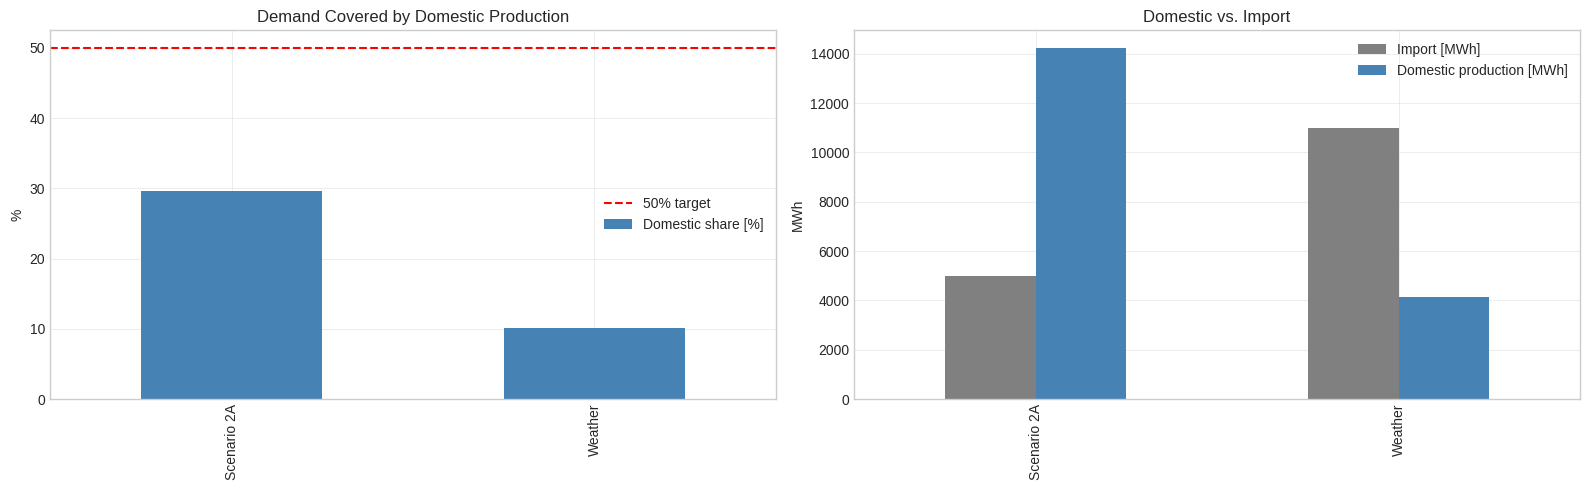

,Domestic share [%],Import [MWh],Domestic production [MWh]
Scenario 2A,0.3,4976.8,14242.4
Weather,0.1,11002.8,4134.6


,Domestic share [%],Import [MWh],Domestic production [MWh]
Scenario 2A,0.3,4976.8,14242.4
Weather,0.1,11002.8,4134.6


In [420]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

(kpis.loc[["Domestic share [%]"]] * 100).T \
    .plot(kind="bar", ax=axes[0], legend=False, color="steelblue")
axes[0].axhline(50, color="red", linewidth=1.5, linestyle="--", label="50% target")
axes[0].legend()
axes[0].set_title("Demand Covered by Domestic Production")
axes[0].set_ylabel("%")

kpis.loc[["Import [MWh]", "Domestic production [MWh]"]].T \
    .plot(kind="bar", ax=axes[1], color=["grey", "steelblue"]); axes[1].set_title("Domestic vs. Import"); axes[1].set_ylabel("MWh")

plt.tight_layout(); plt.show()

es_table = kpis.loc[["Domestic share [%]", "Import [MWh]", "Domestic production [MWh]"]].T
display(es_table.round(1))
display(
    es_table.round(1).style
        .set_caption("Energy Security by Scenario")
        .format("{:.1f}")
        .background_gradient(cmap="Reds", axis=0)
)

### Final Reflections for Part 2: Priorities & Trade-offs